# 初步

- 特征工程
- 回归模型：线性，非线性

## 导入

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import time
import os

from scipy import stats
from sklearn.compose import ColumnTransformer,make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder,LabelEncoder, FunctionTransformer,TargetEncoder,PolynomialFeatures
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso,LassoCV, Ridge,RidgeCV,ElasticNetCV, ElasticNet, LinearRegression,BayesianRidge
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import TransformedTargetRegressor
from sklearn.feature_selection import f_regression, SelectKBest
from sklearn.metrics import root_mean_squared_error
import gc
import warnings
from contextlib import contextmanager

gc.enable()
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
plt.rcParams['figure.figsize'] = (8,6) 
plt.rcParams['figure.dpi'] = 100

sns.set_theme(style="whitegrid", palette="Set1")

print(f'pd: {pd.__version__}')

pd: 2.3.3


In [2]:
traindata = pd.read_csv('data/train.csv',index_col='Id')
testdata = pd.read_csv('data/test.csv',index_col='Id')

In [3]:
traindata.shape

(1460, 80)

In [4]:
traindata.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
traindata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

In [6]:
traindata.describe(include='all')

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,5,NaN,NaN,2,2,4,4,2,5,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,1151,NaN,NaN,1454,50,925,1311,1459,1052,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


In [7]:
traindata.dtypes

MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 80, dtype: object

## submit

In [8]:

def submit(ids, pred, name, feature_count=None):
    """
    ids: 测试集的id
    pred: 模型预测概率
    name: 你的实验备注 (如 'lgb_v1', 'baseline')
    feature_count: 可选，记录模型使用了多少个特征
    """
    # 1. 创建提交 DataFrame
    submit_df = pd.DataFrame({
        'ID': ids,
        'SalePrice': pred
    })

    # 2. 生成时间戳 (格式: 0213_1530)
    timestamp = time.strftime("%m%d_%H%M")
    
    # 3. 构造文件名
    # 格式: 0213_1530_lgb_v1_f542.csv
    f_str = f"_f{feature_count}" if feature_count else ""
    filename = f"{timestamp}_{name}{f_str}.csv"
    
    # 4. 确保保存目录存在 (可选)
    if not os.path.exists('submissions'):
        os.makedirs('submissions')
    
    save_path = os.path.join('submissions', filename)
    
    # 5. 保存并打印提示
    submit_df.to_csv(save_path, index=False)
    
    return submit_df


## 字段说明
来自AI

🏠 房屋基本属性与位置

这些字段决定了房子的“骨架”和地段：

* **MSSubClass**: 房屋类型（如：1层现代风格、2层复古风格等）。
* **MSZoning**: 土地分区（如：住宅区、商业区、农业区）。
* **LotFrontage**: 房屋连接街道的距离（英尺）。
* **LotArea**: 地块面积（平方英尺）。
* **Street / Alley**: 道路/巷道的铺设类型（如：碎石、柏油）。
* **LotShape**: 地块形状（是否规整）。
* **LandContour**: 地形平坦度（如：平坦、有坡度、凹陷）。
* **Neighborhood**: 艾姆斯市内的具体社区位置。
* **BldgType**: 住宅类型（独栋、联排等）。
* **HouseStyle**: 住宅风格（一层、二层、半层等）。

🌟 整体品质与年代

* **OverallQual**: 整体材料和装饰评分（1-10分）。
* **OverallCond**: 整体状态评分（1-10分）。
* **YearBuilt**: 建造年份。
* **YearRemodAdd**: 改建年份。

🧱 外部与结构细节

* **RoofStyle / RoofMatl**: 屋顶类型和材料。
* **Exterior1st / Exterior2nd**: 房屋外墙覆盖物。
* **MasVnrType / MasVnrArea**: 砖石饰面类型及面积。
* **ExterQual / ExterCond**: 外部材料的质量和现状评分。
* **Foundation**: 地基类型（如：混凝土、砖、石头）。

🕳️ 地下室情况

* **BsmtQual / BsmtCond**: 地下室的高度评价和质量评分。
* **BsmtExposure**: 花园式地下室的采光/出口情况。
* **BsmtFinType1 / BsmtFinSF1**: 第一类型地下室完工面积及类型。
* **BsmtFinType2 / BsmtFinSF2**: 第二类型地下室完工面积。
* **BsmtUnfSF**: 未完工地下室面积。
* **TotalBsmtSF**: 地下室总面积。

🌡️ 公用设施与系统

* **Heating / HeatingQC**: 供暖类型和质量评分。
* **CentralAir**: 是否有中央空调（Y/N）。
* **Electrical**: 电气系统类型。

📐 居住面积与房间

* **1stFlrSF / 2ndFlrSF**: 一层/二层面积。
* **LowQualFinSF**: 低质量完工面积（所有楼层）。
* **GrLivArea**: 地面以上居住面积总和。
* **BsmtFullBath / BsmtHalfBath**: 地下室全卫/半卫数量。
* **FullBath / HalfBath**: 地面上全卫/半卫数量。
* **BedroomAbvGr**: 地面上卧室数量。
* **KitchenAbvGr / KitchenQual**: 厨房数量及质量评分。
* **TotRmsAbvGrd**: 地面上房间总数（不含卫浴）。
* **Fireplaces / FireplaceQu**: 壁炉数量及质量。

🚗 车库与附属设施

* **GarageType / GarageYrBlt**: 车库位置、建造年份。
* **GarageFinish / GarageCars / GarageArea**: 车库装修情况、车位数、面积。
* **GarageQual / GarageCond**: 车库质量和现状。
* **PavedDrive**: 车道铺设情况。
* **WoodDeckSF / OpenPorchSF / EnclosedPorch / 3SsnPorch / ScreenPorch**: 露台、走廊等各类户外空间的面积。
* **PoolArea / PoolQC**: 泳池面积及质量。
* **Fence**: 围栏质量。
* **MiscFeature / MiscVal**: 其他杂项特征（如：网球场、棚屋）及其价值。

💰 销售信息

* **MoSold / YrSold**: 售出月份和年份。
* **SaleType**: 销售类型（如：现金、贷款、法拍）。
* **SaleCondition**: 销售条件（如：正常交易、家庭内部转让）。
* **SalePrice**: **目标变量**，房屋售价（美元）。

## EDA
描述了数据特征探索的全部过程。 

EDA过程进行了一些修改：缺失值删除列或者行，异常值删除样本行，还有转变dtype,类型编码，log变换等，

从EDA到pipeline的时候，注意的：
1. 删除样本行的操作，应该在pipeline之前，在train上进行
2. 填充缺失值、标准化、类型编码，在pipeline中，train上fit，test上transform
3. 缺失值删除列、log变换，在pipeline中或者之前

In [9]:
eda_data = traindata.copy() # 方便探索，不修改traindata

traindata会进行样本行删除

### metric

Root-Mean-Squared-Error (RMSE) between the logarithm of the predicted value and the logarithm of the observed sales price. 

### 修正dtypes

In [10]:
date_cols = ['GarageYrBlt','YearRemodAdd', 'YearBuilt', 'YrSold', 'MoSold']
eda_data[date_cols] = eda_data[date_cols].astype('datetime64[us]')
eda_data['GarageYrBlt'] = eda_data['GarageYrBlt'].dt.year
eda_data['YearRemodAdd'] = eda_data['YearRemodAdd'].dt.year
eda_data['YearBuilt'] = eda_data['YearBuilt'].dt.year
eda_data['YrSold'] = eda_data['YrSold'].dt.year
eda_data['MoSold'] = eda_data['MoSold'].dt.month

数字表示类别，不具备数值意义：

*MSSubClass*是类别

In [11]:
eda_data['MSSubClass'] = eda_data['MSSubClass'].astype('category')

定序特征转换为数值类型：

In [12]:
eda_data['ExterQual'] = eda_data['ExterQual'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0})
eda_data['BsmtCond'] = eda_data['BsmtCond'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0})
eda_data['BsmtFinType1'] = eda_data['BsmtFinType1'].map({'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'NA':0})
eda_data['BsmtFinType2'] = eda_data['BsmtFinType2'].map({'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'NA':0})
eda_data['BsmtQual'] = eda_data['BsmtQual'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0})
eda_data['KitchenQual'] = eda_data['KitchenQual'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0})
eda_data['GarageQual'] = eda_data['GarageQual'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0})
eda_data['GarageCond'] = eda_data['GarageCond'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0})
eda_data['HeatingQC'] = eda_data['HeatingQC'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0})
eda_data['FireplaceQu'] = eda_data['FireplaceQu'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0})
eda_data['PoolQC'] = eda_data['PoolQC'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0})
eda_data['Fence'] = eda_data['Fence'].map({'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'NA': 0})

### 目标SalePrice

Text(0.5, 1.0, 'SalePrice distribution')

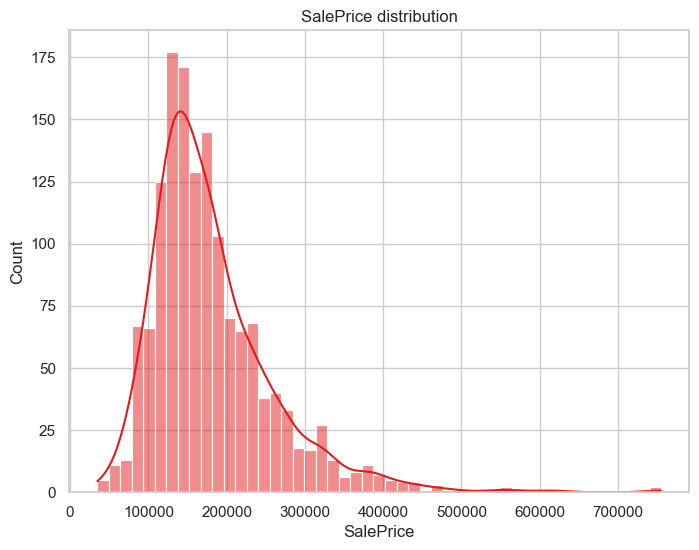

In [13]:
ax = sns.histplot(data=eda_data, x='SalePrice',kde=True)
ax.set_title('SalePrice distribution')

明显是左偏分布、尖峰长尾

In [14]:
skew = eda_data['SalePrice'].skew()
kurt = eda_data['SalePrice'].kurt()
print(f'SalePrice: skew {skew}, kurt {kurt}')

SalePrice: skew 1.8828757597682129, kurt 6.536281860064529


### 数值特征与SalePrice相关性
所有数值包括 定序特征

In [15]:
eda_data.select_dtypes(include=['number']).columns

Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'ExterQual', 'BsmtQual', 'BsmtCond',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'HeatingQC', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Fireplaces', 'FireplaceQu', 'GarageYrBlt', 'GarageCars', 'GarageArea',
       'GarageQual', 'GarageCond', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'PoolQC',
       'Fence', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

<Axes: >

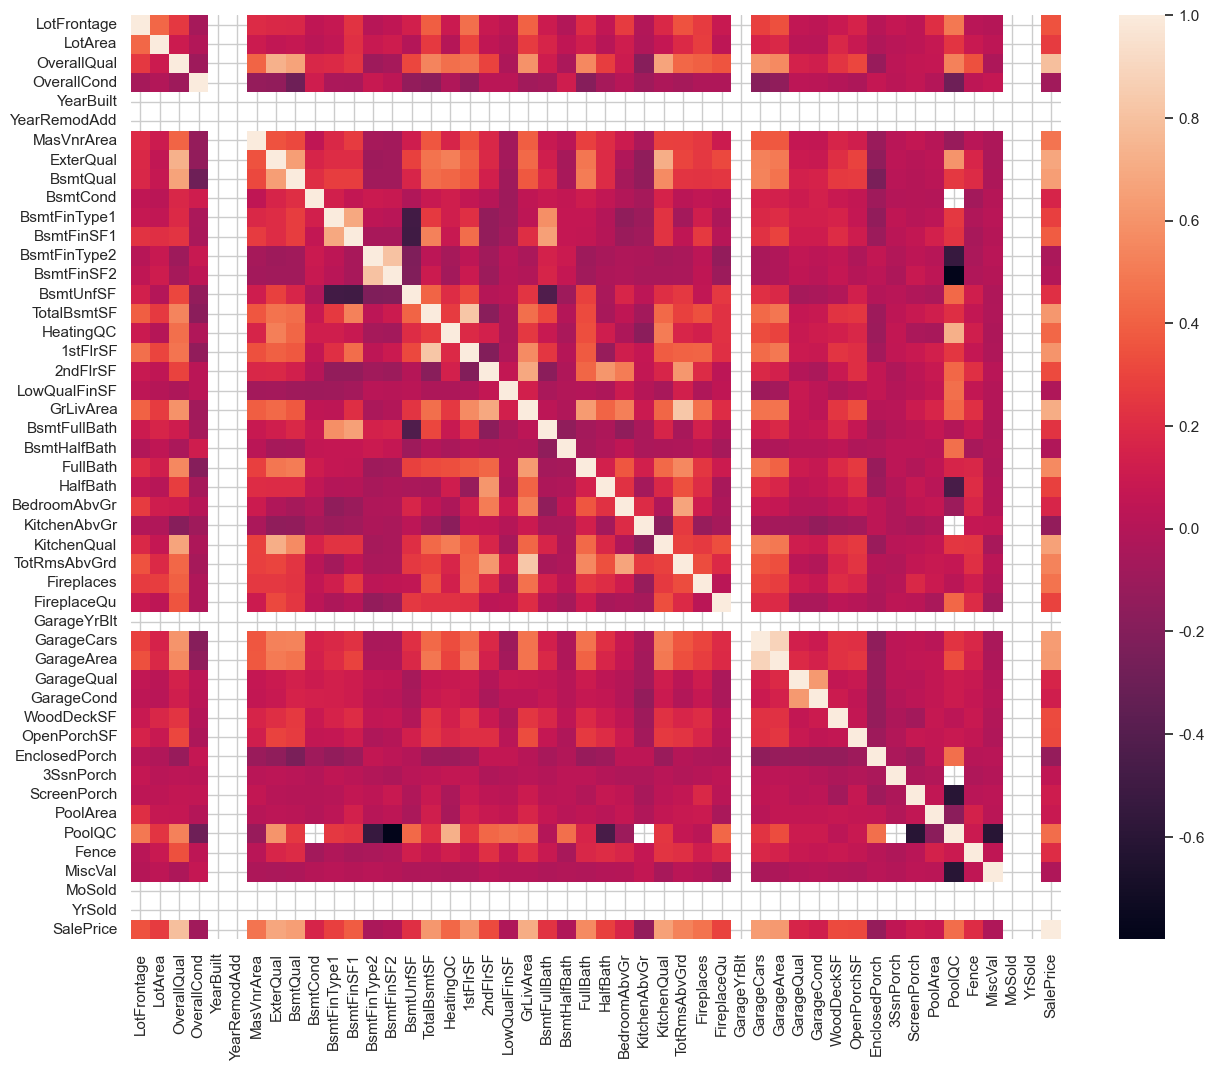

In [16]:
plt.figure(figsize=(15, 12))
corrs = eda_data.corr(numeric_only=True)
sns.heatmap(data=corrs)

明显地，黄色方块
- 有几个高度共线特征
- `SalePrice`的几个相关特征：`GrLivArea`,`OverallQual`..


着重看下与`SalePrice`几个高相关特征

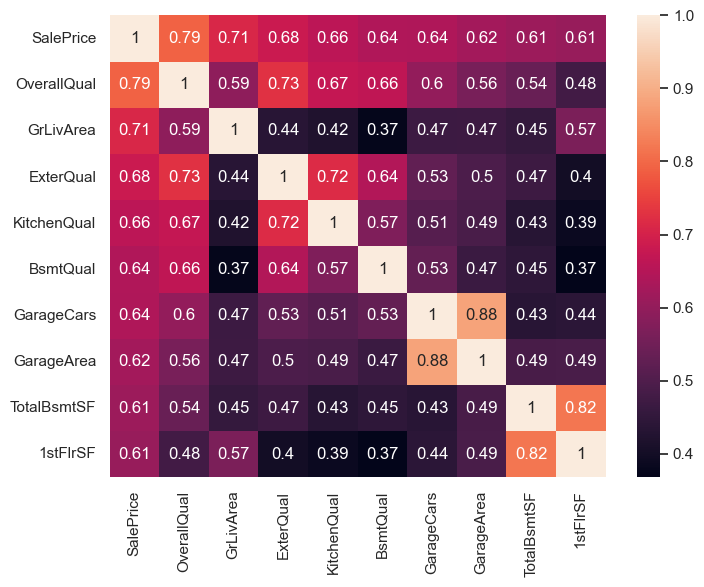

In [17]:
high10_cols = corrs.nlargest(10, 'SalePrice').index.tolist() 
high10_corrs = eda_data[high10_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(data=high10_corrs, annot=True)
plt.show()

理解下这几个特征：
- *OverallQual* 房屋装潢很重要！
- *GrLivArea* 地上楼层活动面积，
- *GarageCars* 车位数，*GarageArea* 车库面积 。 这两个是共线强相关的~
- *TotalBsmtSF* 地下室面积，*1stFlrSF* 一层面积。 这两个是共线强相关的~
- *FullBath* 地上楼层带有洗澡全设施的数量！！
- *ExterQual* 
- *KitchenQual*
- *BsmtQual*

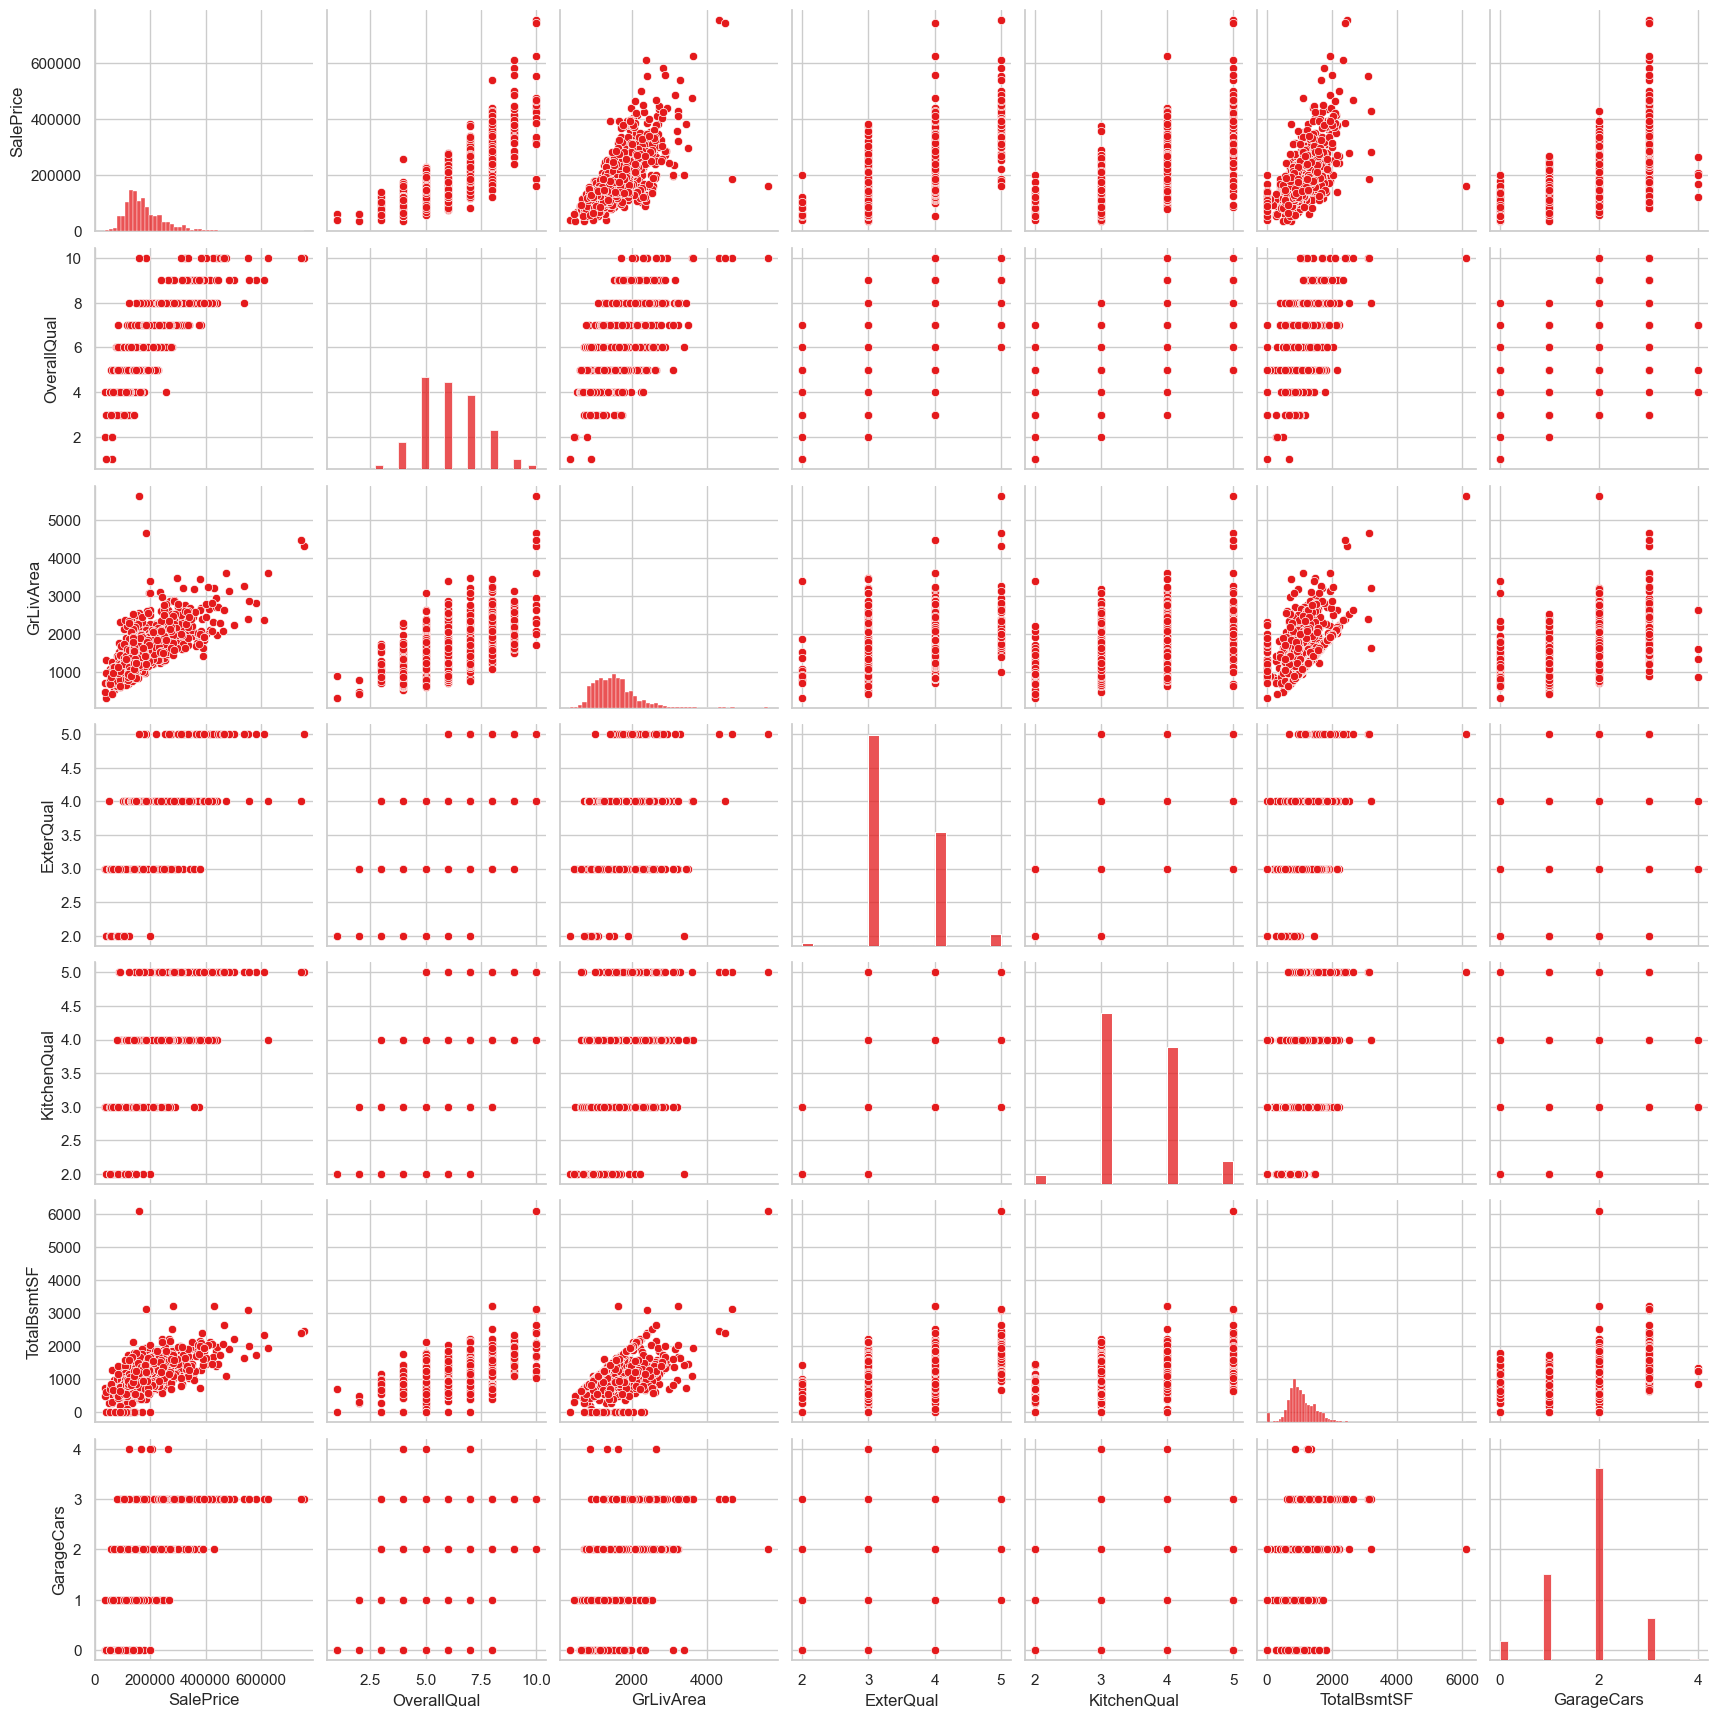

In [18]:
cols = ['SalePrice','OverallQual','GrLivArea','ExterQual','KitchenQual','TotalBsmtSF','GarageCars']
ax = sns.pairplot(data=eda_data[cols])

发现：

有一些很像边界的线： 比如`TotalBsmtSF` 总是小于`GrLivArea`这是合理的，地上楼层活动面积大于地下室面积


随着建筑年限靠近，价格指数级上升


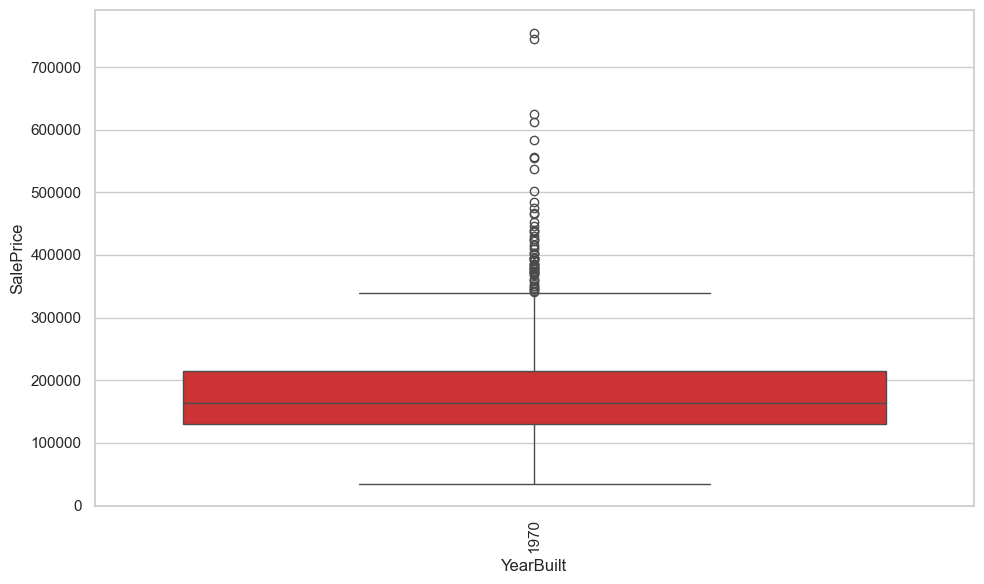

In [19]:
plt.figure(figsize=(10,6))
ax = sns.boxplot(data=eda_data, x= 'YearBuilt', y='SalePrice')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 分类特征与目标ANOVA

如何在这么多特征找到那些关键特征？？

我们通过ANOVA(方差分析)，F统计量检验来找一些关键特征

In [20]:
eda_data.select_dtypes(include=['object', 'category']).columns

Index(['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour',
       'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
       'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterCond', 'Foundation',
       'BsmtExposure', 'Heating', 'CentralAir', 'Electrical', 'Functional',
       'GarageType', 'GarageFinish', 'PavedDrive', 'MiscFeature', 'SaleType',
       'SaleCondition'],
      dtype='object')

In [21]:
def stat_category_features(df, n_high = 10):
    cols = df.select_dtypes(include=['object', 'category']).columns
    le = LabelEncoder()
    y = df[['SalePrice']]
    X = pd.DataFrame()
    for col in cols:
        X[col] = le.fit_transform(df[col])
    f_stats, p_values = f_regression(X = X, y=y)
    result = pd.DataFrame(index=X.columns)
    result['f_score'] = f_stats
    result['p_value'] = p_values
    return result

In [22]:
result = stat_category_features(eda_data)

In [23]:
no_imp_category_features = result[result['p_value'] > 0.05].index

In [24]:
no_imp_category_features

Index(['Street', 'LandContour', 'Utilities', 'LandSlope', 'Condition2'], dtype='object')

对于$p>0.05$的特征，我们认为F统计量是不可信的随机的。即分类对价格影响是随机的，可以删除

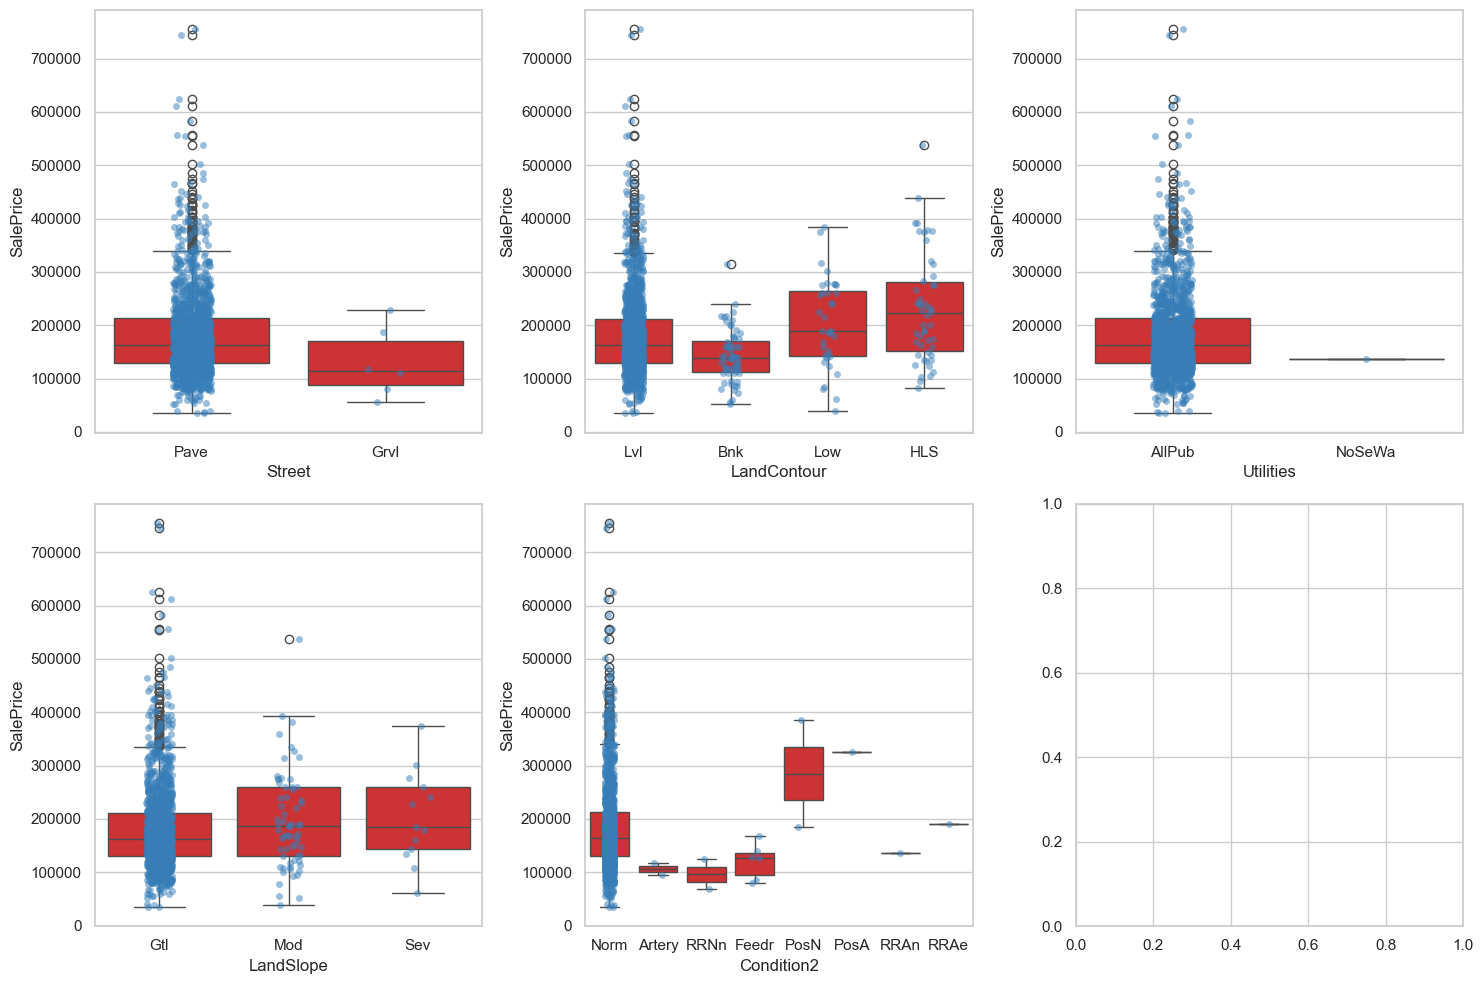

In [25]:
fig, axes = plt.subplots(2,3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(no_imp_category_features):
    sns.boxplot(data=eda_data, x=col, y='SalePrice', ax = axes[i])
    sns.stripplot(data=eda_data, x=col, y='SalePrice', ax=axes[i], alpha=0.5)
plt.tight_layout()
plt.show()

确实地，可以看到，这些特征几乎都只用了一个类别！

我们来看下找到的前几个关键特征

In [26]:
result[result['p_value'] < 0.05].sort_values(by='f_score',ascending=False).head(9)

,f_score,p_value
GarageFinish,629.844106,7.922769e-116
GarageType,303.848427,5.866699e-62
Foundation,249.840256,4.579866e-52
BsmtExposure,153.953618,1.112827e-33
MasVnrType,125.530544,5.231103e-28
LotShape,101.893942,3.320712e-23
CentralAir,98.305344,1.809506e-22
Electrical,85.006587,1.008341e-19
PavedDrive,82.454424,3.418340e-19


In [27]:
imp_category_features = result[result['p_value'] < 0.05].sort_values(by='f_score',ascending=False).head(9).index

In [28]:
imp_category_features

Index(['GarageFinish', 'GarageType', 'Foundation', 'BsmtExposure',
       'MasVnrType', 'LotShape', 'CentralAir', 'Electrical', 'PavedDrive'],
      dtype='object')

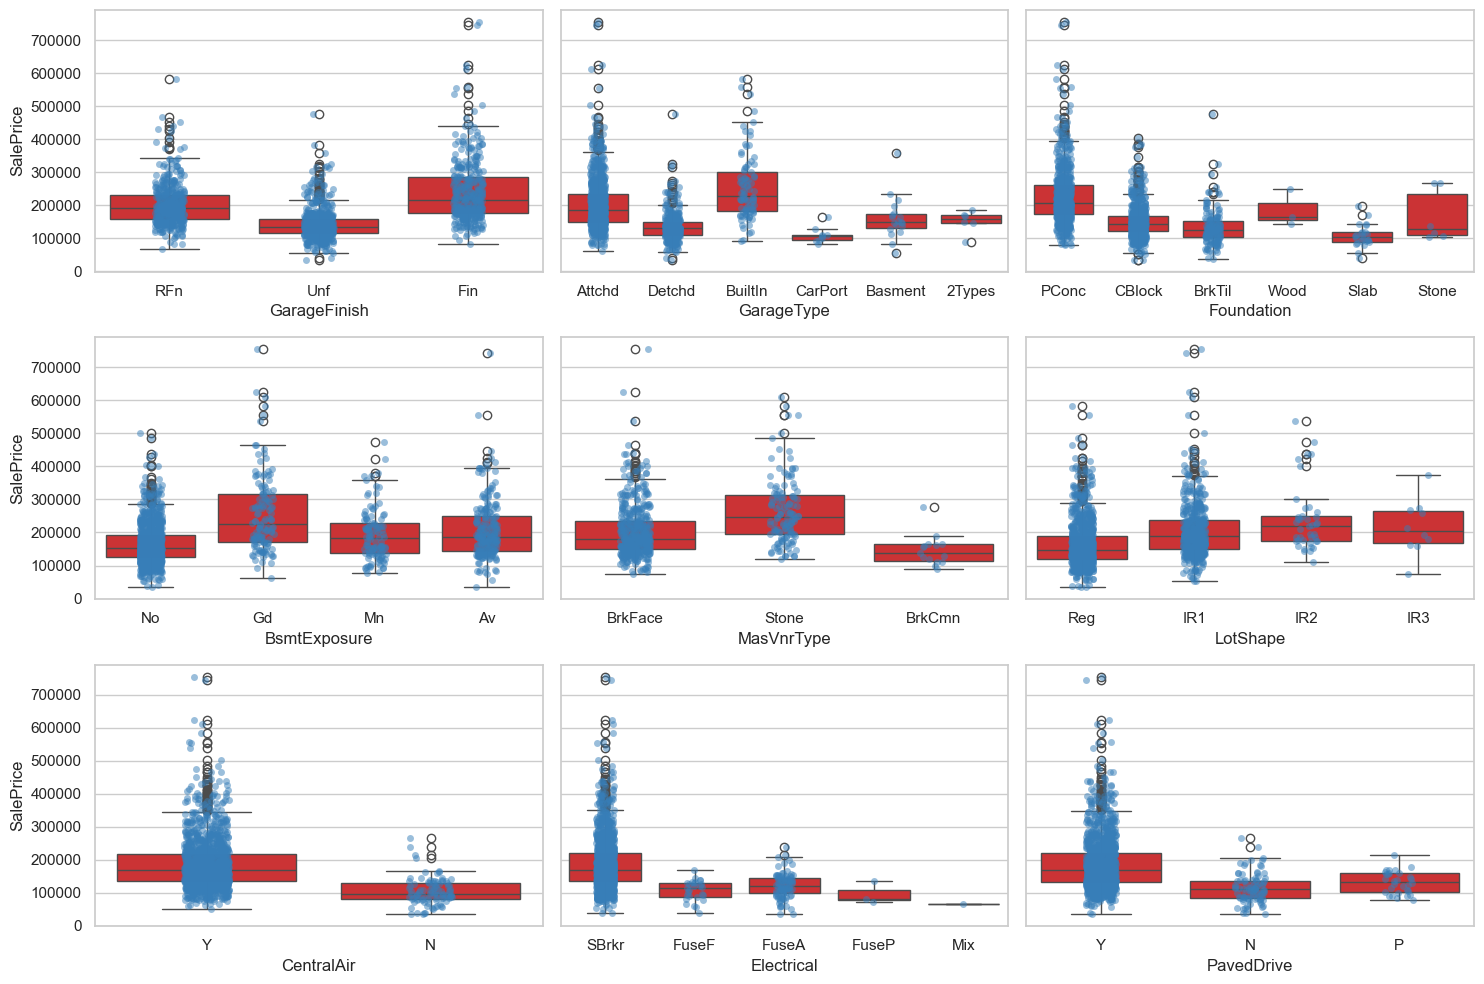

In [29]:
fig, axes = plt.subplots(3,3, figsize=(15, 10), sharey=True)
axes = axes.flatten()
for i, col in enumerate(imp_category_features):
    sns.boxplot(data=eda_data, x=col, y='SalePrice', ax=axes[i])
    sns.stripplot(data=eda_data, x=col, y='SalePrice', ax=axes[i], alpha=0.5)
plt.tight_layout()
plt.show()

确实的，都有着不错的效果~😊

一些特别的（后续训练出现的）

In [30]:
result[result.index == 'MSZoning']

,f_score,p_value
MSZoning,41.762896,1.401300e-10


<Axes: xlabel='MSZoning', ylabel='SalePrice'>

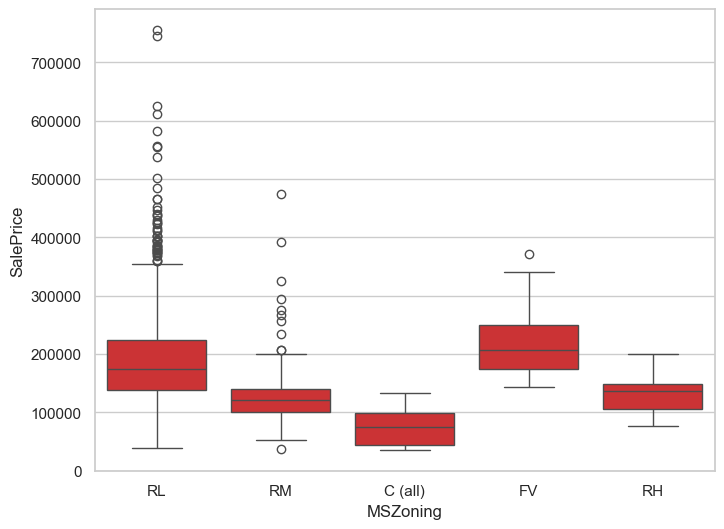

In [31]:
sns.boxplot(data=eda_data, x='MSZoning', y='SalePrice')

### missing
先处理缺失值
- 缺失的程度
- 缺失是否有规律？还是人为异常？

In [32]:
total = eda_data.isnull().sum()
percent = eda_data.isnull().sum() / eda_data.shape[0]
missing_data = pd.concat([total, percent], axis=1, keys=['total', 'percent'])
missing_data.sort_values(by='percent', ascending=False).head()

,total,percent
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
MasVnrType,872,0.597260


In [33]:
missing_data[missing_data['percent'] > 0.15]

,total,percent
LotFrontage,259,0.177397
Alley,1369,0.937671
MasVnrType,872,0.597260
FireplaceQu,690,0.472603
PoolQC,1453,0.995205
Fence,1179,0.807534
MiscFeature,1406,0.963014


缺失比例大于15%，我们考虑删除特征: 

主要都是质量材料相关的缺失，应该不重要，可以删除

In [34]:
missing_data[(missing_data['percent'] <= 0.15) & (missing_data['percent'] >0)]

,total,percent
MasVnrArea,8,0.005479
BsmtQual,37,0.025342
BsmtCond,37,0.025342
BsmtExposure,38,0.026027
BsmtFinType1,37,0.025342
BsmtFinType2,38,0.026027
Electrical,1,0.000685
GarageType,81,0.055479
GarageYrBlt,81,0.055479
GarageFinish,81,0.055479


对于缺失小于15%的，
- *Bsmt* 有相关的 TotalBsmtSF 表示。  删除特征
- *Garage* 有相关的 *GarageCars*。  删除特征
- `Electrical`删除行就可

In [35]:
eda_data[eda_data['Electrical'].isnull()].index

Index([1380], dtype='int64', name='Id')

In [36]:
eda_data = eda_data.drop(index=eda_data[eda_data['Electrical'].isnull()].index,axis=0)
traindata = traindata.drop(index=eda_data[eda_data['Electrical'].isnull()].index,axis=0)

In [37]:
missing_remove_num_cols = {'MasVnrArea'}
missing_remove_cat_cols = {'Alley', 'MasVnrType', 'Fence', 'MiscFeature','GarageType', 'GarageFinish'}
missing_remove_ord_cols = {'PoolQC', 'FireplaceQu','BsmtQual','BsmtCond','BsmtExposure', 'BsmtFinType1','BsmtFinType2', 'GarageQual', 'GarageCond'}

In [38]:
eda_data['GarageYrBlt'] = eda_data['GarageYrBlt'].fillna(eda_data['YearBuilt'])

In [39]:
eda_data.isnull().sum().sort_values(ascending=False)

PoolQC         1452
MiscFeature    1405
Alley          1368
Fence          1178
MasVnrType      871
               ... 
ExterCond         0
ExterQual         0
Exterior2nd       0
Exterior1st       0
SalePrice         0
Length: 80, dtype: int64

先进性粗略的填充使用median,none

### 异常值
- 删除行：

**应该聚焦于那些关键的特征！**：

In [40]:
imp_numeric_cols =[
   'OverallQual','TotalBsmtSF', 'GrLivArea','1stFlrSF'
]
imp_category_cols = [
   'Foundation','LotShape', 'CentralAir','Electrical', 'PavedDrive'
    ]

关于离群异常点的定义，不能使用简单的IQR，很多数值特征都是长尾的，所需需要log变换

#### 目标异常

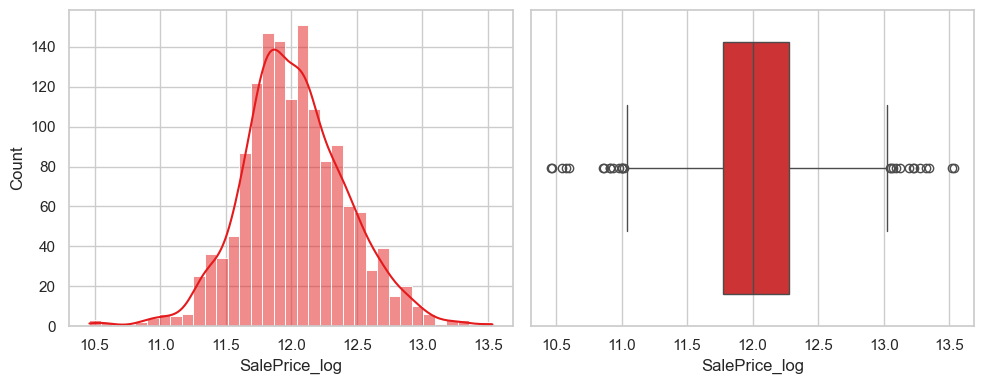

In [41]:
eda_data['SalePrice_log'] = np.log1p(eda_data['SalePrice'])
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,4))
sns.histplot(data=eda_data, x='SalePrice_log', kde=True, ax=ax1)
sns.boxplot(data=eda_data, x='SalePrice_log', ax=ax2)
plt.tight_layout()
plt.show()

#### 双变量异常
散点异常：删除点

In [42]:
eda_data[imp_numeric_cols]

,OverallQual,TotalBsmtSF,GrLivArea,1stFlrSF
Id,,,,
1,7,856,1710,856
2,6,1262,1262,1262
3,7,920,1786,920
4,7,756,1717,961
5,8,1145,2198,1145
...,...,...,...,...
1456,6,953,1647,953
1457,6,1542,2073,2073
1458,7,1152,2340,1188


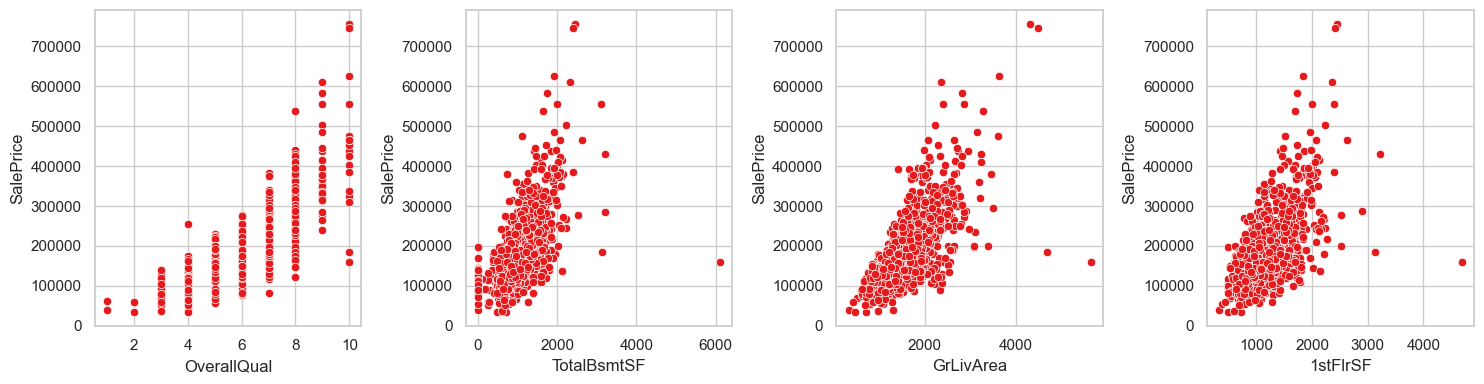

In [43]:
fig,axes = plt.subplots(1,4, figsize=(15,4))
axes = axes.flatten()
for i,col in enumerate(imp_numeric_cols):
    sns.scatterplot(data=eda_data, x=col, y='SalePrice', ax = axes[i])
plt.tight_layout()
plt.show()

有一些离群点

In [44]:
eda_data[(eda_data['GrLivArea']>4000) & (eda_data['SalePrice']<200000)]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log
Id,,,,,,,,,,,,,,,,,,,,,
524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,Inside,...,NaN,NaN,NaN,0,1,1970,New,Partial,184750,12.126764
1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,Corner,...,4.0,NaN,NaN,0,1,1970,New,Partial,160000,11.982935


In [45]:
eda_data[eda_data['TotalBsmtSF']>5000]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log
Id,,,,,,,,,,,,,,,,,,,,,
1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,Corner,...,4.0,NaN,NaN,0,1,1970,New,Partial,160000,11.982935


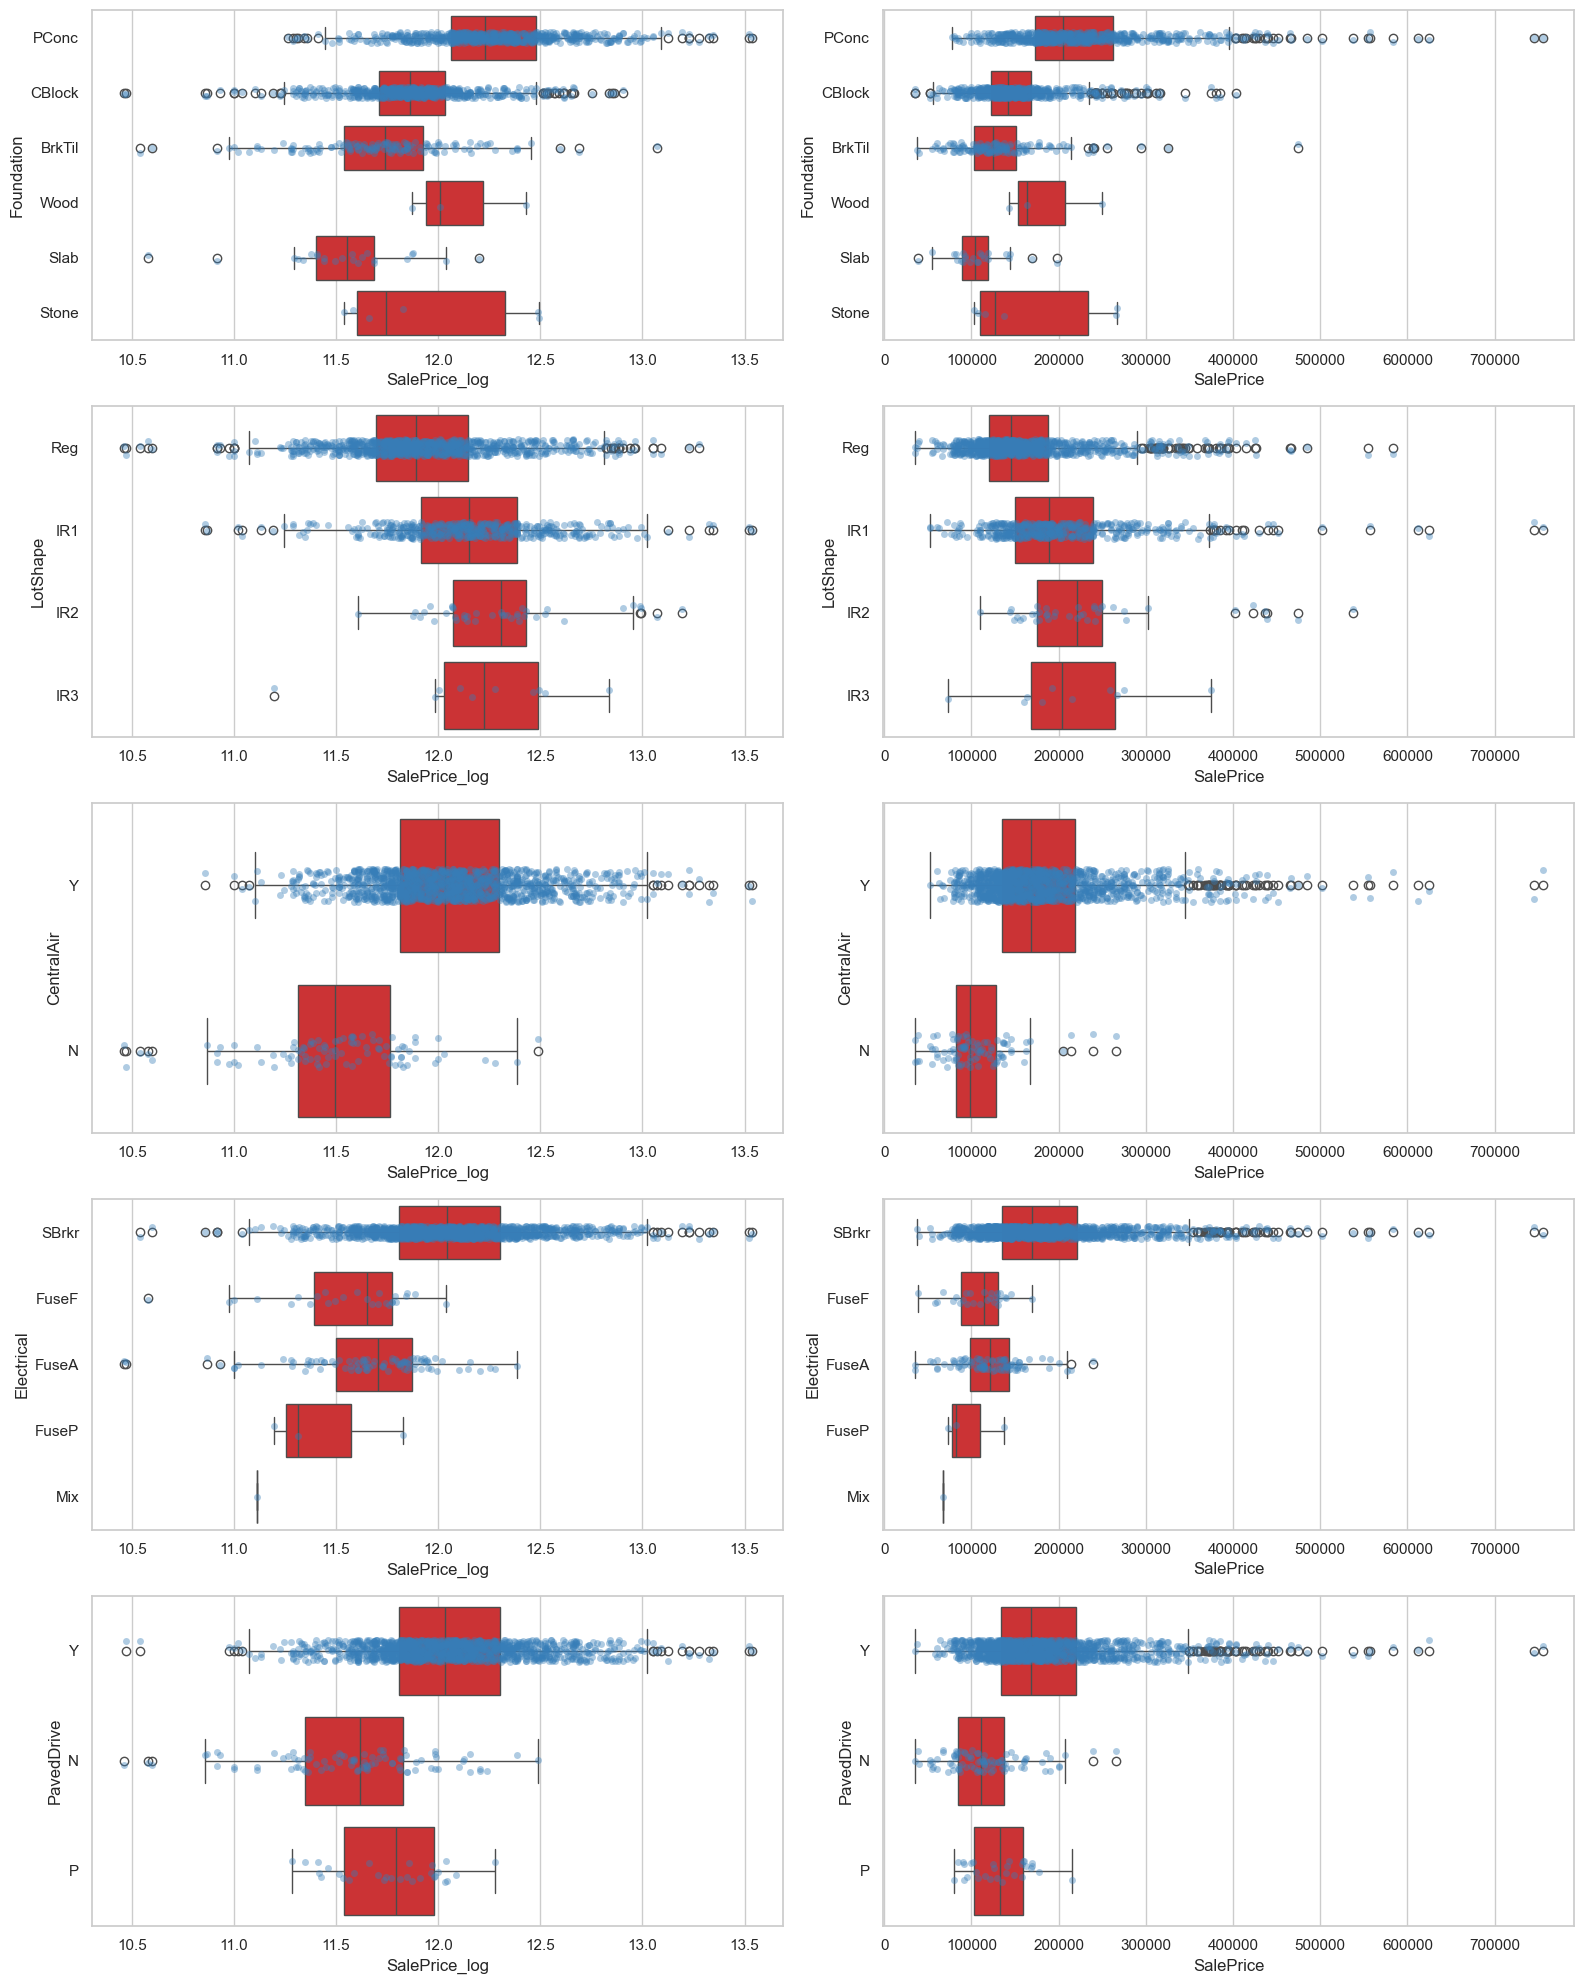

In [46]:
fig, axes = plt.subplots(len(imp_category_cols), 2, figsize=(16, 4 * len(imp_category_cols)))

for i, col in enumerate(imp_category_cols):
    sns.boxplot(data=eda_data, x='SalePrice_log', y=col, ax=axes[i, 0])
    sns.stripplot(data=eda_data, x='SalePrice_log', y=col, ax=axes[i, 0], alpha=0.4)

    sns.boxplot(data=eda_data, x='SalePrice', y=col, ax=axes[i, 1])
    sns.stripplot(data=eda_data, x='SalePrice', y=col, ax=axes[i, 1], alpha=0.4)
plt.tight_layout()
plt.show()


In [47]:
eda_data[(eda_data['Foundation'] == 'PConc') & (eda_data['SalePrice'] > 700000)]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log
Id,,,,,,,,,,,,,,,,,,,,,
692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,Corner,...,NaN,NaN,NaN,0,1,1970,WD,Normal,755000,13.534474
1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,Corner,...,5.0,3.0,NaN,0,1,1970,WD,Abnorml,745000,13.521141


In [48]:
eda_data[(eda_data['Foundation'] == 'BrkTil') & (eda_data['SalePrice'] > 400000)]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log
Id,,,,,,,,,,,,,,,,,,,,,
186,75,RM,90.0,22950,Pave,NaN,IR2,Lvl,AllPub,Inside,...,NaN,4.0,NaN,0,1,1970,WD,Normal,475000,13.071072


In [49]:
eda_data[(eda_data['LotShape'] == 'IR1') & (eda_data['SalePrice'] > 700000)]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log
Id,,,,,,,,,,,,,,,,,,,,,
692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,Corner,...,NaN,NaN,NaN,0,1,1970,WD,Normal,755000,13.534474
1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,Corner,...,5.0,3.0,NaN,0,1,1970,WD,Abnorml,745000,13.521141


#### 剔除异常行

In [50]:
dropids = [524, 1299, 692, 1183,186]

In [51]:
# 来自model训练后的离散点分析，如需复现这几个ids，请注释掉，然后查看model分析
dropids.append(441) 
dropids.extend([971, 89, 689]) 

In [52]:
eda_data = eda_data.drop(dropids, axis=0)
traindata = traindata.drop(dropids, axis=0)

### log变换
log 减小了远端大值误差。 增大了近端小值误差。
结果就是：远端不离群了，小端更加离群了

<Axes: xlabel='TotalBsmtSF', ylabel='Count'>

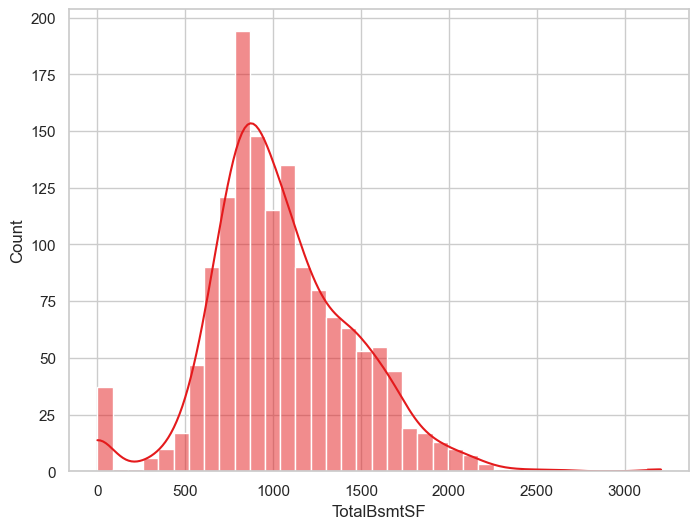

In [53]:
sns.histplot(eda_data, x='TotalBsmtSF',kde=True)

- TotalBsmtSF = 0 值太多。 这代表没有地下室。  **我们不能对0做log变换**
- 远端有离群点

为此，我们需要创建一个特征，为了0值。只对非0值做转换

In [54]:
eda_data['HasBsmt'] = 1
eda_data['HasBsmt'][eda_data[eda_data['TotalBsmtSF'] == 0].index] = 0

In [55]:
eda_data.loc[eda_data['HasBsmt']==1, 'TotalBsmtSF'] = np.log(eda_data.loc[eda_data['HasBsmt']==1, 'TotalBsmtSF'])

<Axes: xlabel='TotalBsmtSF', ylabel='Count'>

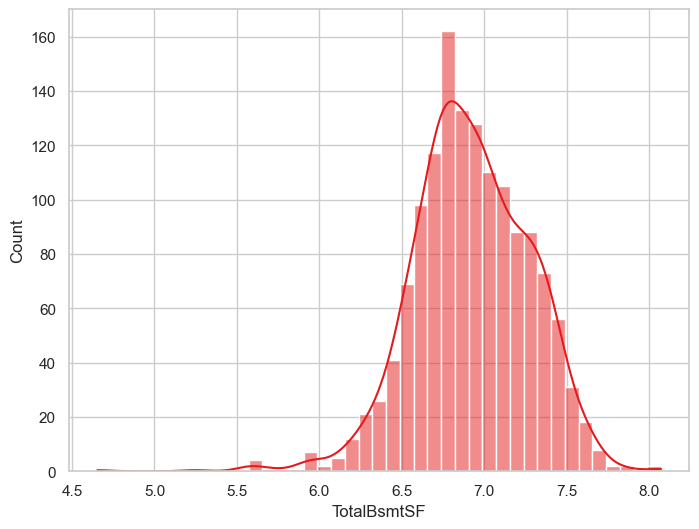

In [56]:
sns.histplot(eda_data[eda_data['HasBsmt'] == 1], x='TotalBsmtSF',kde=True)

### `Gauss-Markon`假设

#### 误差同方差

这里是不严谨的，应该是n维超线性空间的误差。

但是如果误差方差依赖了某个特征，那么就会波动，不恒定。

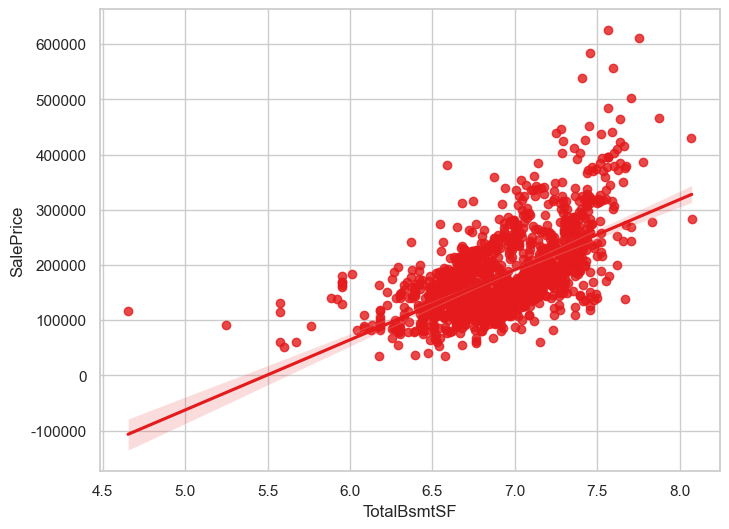

In [57]:
ax = sns.regplot(eda_data[eda_data['HasBsmt'] == 1], x='TotalBsmtSF', y='SalePrice')

以`TotalBsmtSF`特征而言，每个x值，y分布沿着回归线一致，即方差不变

### 误差正态假设
为了后续显著性检验

误差，y，$\beta$ 是正态的

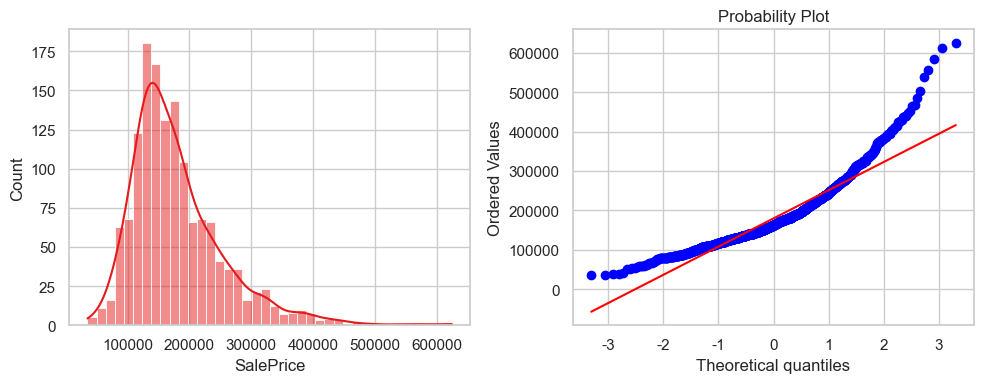

In [58]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
sns.histplot(data=eda_data, x='SalePrice',kde=True, ax= ax1)
res = stats.probplot(eda_data['SalePrice'], plot=ax2)
plt.tight_layout()
plt.show()

数据向上弯表示右偏，红线为正态分布

通过log变换让他更像正态分布

In [59]:
eda_data['SalePrice_log'] = np.log(eda_data['SalePrice'])

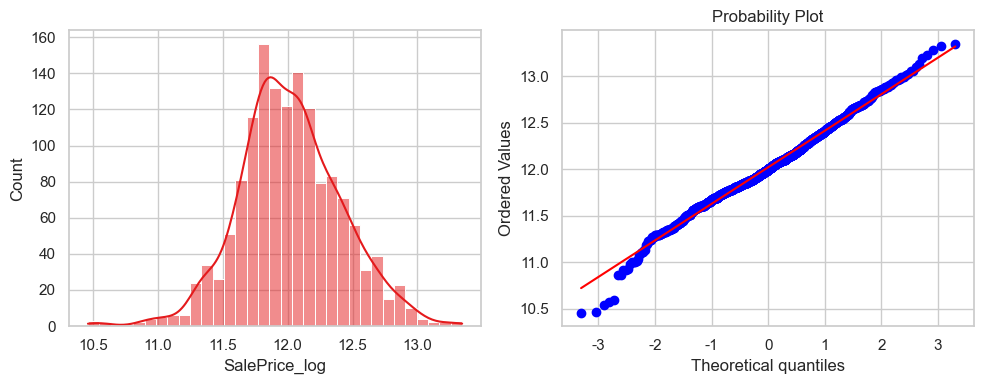

In [60]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
sns.histplot(data=eda_data, x='SalePrice_log',kde=True, ax= ax1)
res = stats.probplot(eda_data['SalePrice_log'], plot=ax2)
plt.tight_layout()
plt.show()

---

```{warning}
下面train和test同步

## 特征选择

对列进行增加，删除，构建新特征

应该阐述我构造的思想~

有些特征与目标也不是线性关系，也得非线性转换

对于线性构造方法，旨在创造一些更具有解释意义的特征，但必须之后删除一些特征，保证满秩。

对于非线性构造方法，旨在捕捉隐藏特征，提高模型上限，

date数据类型可以转为pd.datetime

### 1. 年份
- 年份本身可以是变量，能够表明某些年份房价波动
- 年份构造的age抵消了时间背景，表示age对房价也有波动

探索一下

In [61]:
eda_data['HouseAge'] = eda_data['YrSold'] -eda_data['YearBuilt']

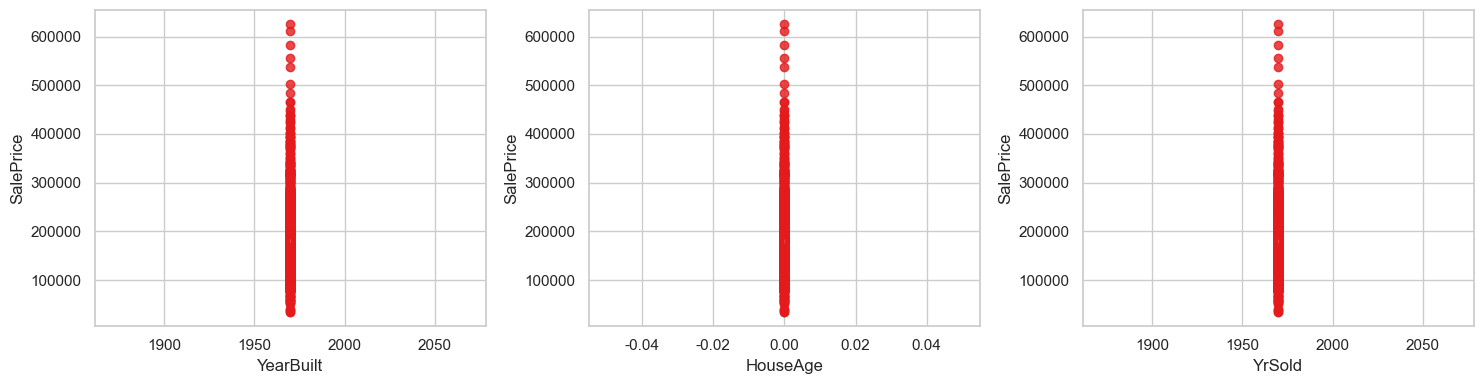

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.regplot(data=eda_data, x='YearBuilt', y = 'SalePrice', ax=axes[0])
sns.regplot(data=eda_data, x='HouseAge', y = 'SalePrice', ax=axes[1])
sns.regplot(data=eda_data, x='YrSold', y = 'SalePrice', ax=axes[2])
plt.tight_layout()
plt.show()

In [63]:
eda_data[['YearBuilt', 'HouseAge']].corr()

,YearBuilt,HouseAge
YearBuilt,NaN,NaN
HouseAge,NaN,NaN


图中表明，`YrSold` 对于构造`HouseAge`影响不大。也因此，相关性大。

结论：不构造`HouseAge`, 删除`YrSold`, 保留`YearBuilt`

### 2. 房屋面积

In [64]:
eda_data['TotalSF'] = eda_data['1stFlrSF'] + eda_data['2ndFlrSF'] + eda_data['TotalBsmtSF']

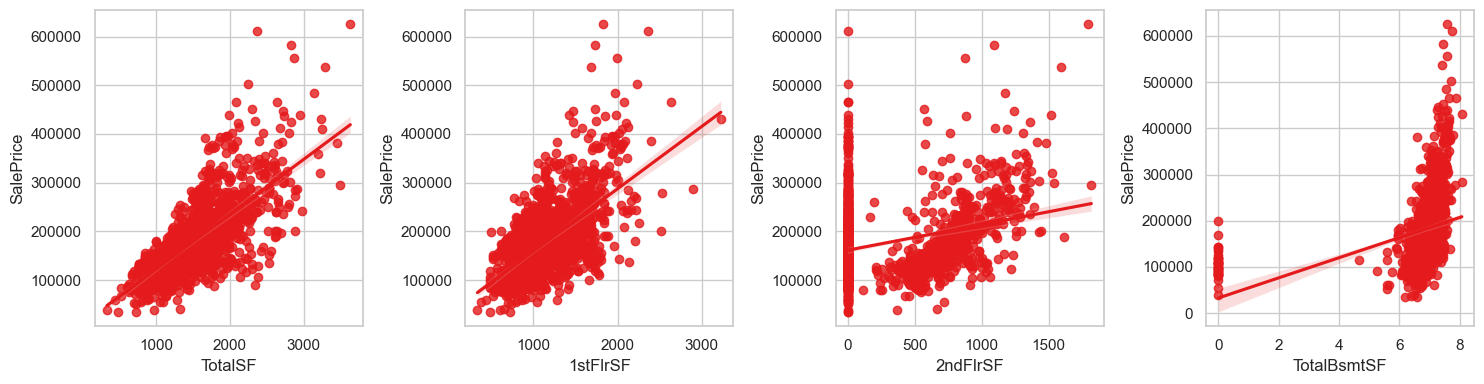

In [65]:
fig, axes = plt.subplots(1, 4, figsize=(15,4))
axes = axes.flatten()
sns.regplot(data=eda_data, x='TotalSF', y = 'SalePrice', ax=axes[0])
sns.regplot(data=eda_data, x='1stFlrSF', y = 'SalePrice', ax=axes[1])
sns.regplot(data=eda_data, x='2ndFlrSF', y = 'SalePrice', ax=axes[2])
sns.regplot(data=eda_data, x='TotalBsmtSF', y = 'SalePrice', ax=axes[3])
plt.tight_layout()
plt.show()

In [66]:
eda_data[['TotalSF', '1stFlrSF', '2ndFlrSF', 'TotalBsmtSF']].corr()

,TotalSF,1stFlrSF,2ndFlrSF,TotalBsmtSF
TotalSF,1.000000,0.527859,0.687724,0.185774
1stFlrSF,0.527859,1.000000,-0.253567,0.268795
2ndFlrSF,0.687724,-0.253567,1.000000,-0.020634
TotalBsmtSF,0.185774,0.268795,-0.020634,1.000000


结论：删除`1stFlrSF`, 保留`TotalSF`

### 3. 房屋面积*质量评分

In [67]:
eda_data['HouseSF_PRODUCT_QUAL'] = eda_data['TotalSF'] * eda_data['OverallQual']


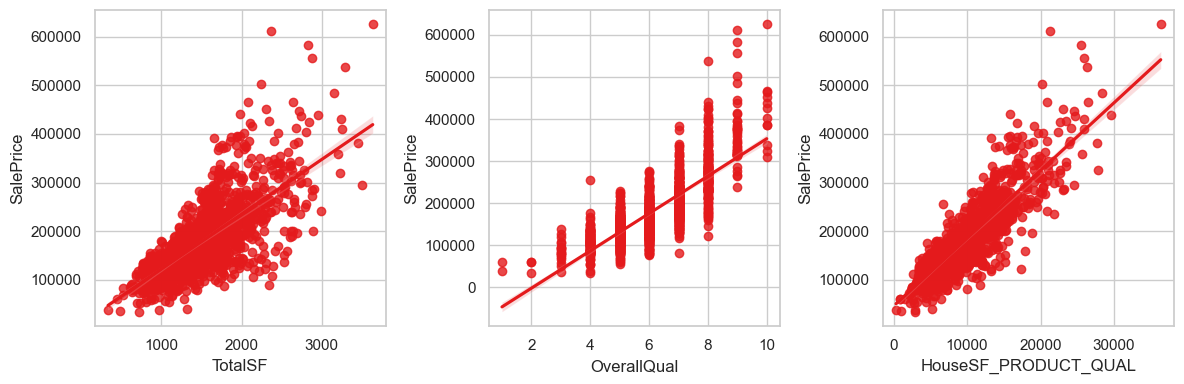

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))
axes = axes.flatten()
sns.regplot(data=eda_data, x='TotalSF', y = 'SalePrice', ax=axes[0])
sns.regplot(data=eda_data, x='OverallQual', y = 'SalePrice', ax=axes[1])
sns.regplot(data=eda_data, x='HouseSF_PRODUCT_QUAL', y = 'SalePrice', ax=axes[2])
plt.tight_layout()
plt.show()

In [69]:
eda_data[['HouseSF_PRODUCT_QUAL', 'OverallQual', 'TotalSF', 'SalePrice']].corr()

,HouseSF_PRODUCT_QUAL,OverallQual,TotalSF,SalePrice
HouseSF_PRODUCT_QUAL,1.000000,0.829884,0.921501,0.869864
OverallQual,0.829884,1.000000,0.588959,0.798928
TotalSF,0.921501,0.588959,1.000000,0.730945
SalePrice,0.869864,0.798928,0.730945,1.000000


可以看到，我们构造的特征对房价有更高的相关性

结论：保留`HouseSF_PRODUCT_QUAL`

## pipeline

### ft pipeline

结合了eda和特征选择两部分。对列进行修改

In [70]:
def ft_features(df):
    """ 
    """
    df['MSSubClass'] = df['MSSubClass'].astype('category')

    df['HasBsmt'] = 1
    df['HasBsmt'][df[df['TotalBsmtSF'] == 0].index] = 0

    df['TotalSF'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']
    df['HouseSF_PRODUCT_QUAL'] = df['TotalSF'] * df['OverallQual']

    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])
    date_cols = ['GarageYrBlt','YearRemodAdd', 'YearBuilt', 'MoSold']
    df[date_cols] = df[date_cols].astype('datetime64[us]')
    df['GarageYrBlt'] = df['GarageYrBlt'].dt.year
    df['YearRemodAdd'] = df['YearRemodAdd'].dt.year
    df['YearBuilt'] = df['YearBuilt'].dt.year
    df['MoSold'] = df['MoSold'].dt.month

    cols_to_remove = [
        '1stFlrSF', 'YrSold',
        *missing_remove_num_cols,
        *missing_remove_cat_cols,
        *missing_remove_ord_cols,
        *no_imp_category_features,
    ]
    remaining_features = [f for f in df.columns if f not in cols_to_remove]

    df = df[remaining_features]

    print(f'feature_features transformer done. ')
    return df
def ft_feature_names_out(transformer, input_features):
    
    cols_to_remove = [
        '1stFlrSF', 'YrSold',
        *missing_remove_num_cols,
        *missing_remove_cat_cols,
        *missing_remove_ord_cols,
        *no_imp_category_features,
    ]
    remaining_features = [f for f in input_features if f not in cols_to_remove]
    
    new_cols = ['HasBsmt', 'TotalSF', 'HouseSF_PRODUCT_QUAL']
    for col in new_cols:
        if col not in remaining_features:
            remaining_features.append(col)
    return remaining_features

In [71]:
ft_pipeline = Pipeline([
    ('ft_features', FunctionTransformer(func=ft_features, feature_names_out=ft_feature_names_out))
])

### date pipeline

In [72]:
def to_int_type(df):
    return df.astype(int)

In [73]:
date_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])
date_pipeline.set_output(transform="pandas") # 配置每步输出df，而不是np arr

,steps,"[('imputer', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


### numeric pipeline

In [74]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # 填充缺失值
    ('log_transform', FunctionTransformer(np.log1p, validate=False, feature_names_out="one-to-one")),  # 取对数
    ('std_scaler', StandardScaler()) # 标准化
])
numeric_pipeline.set_output(transform="pandas") # 配置每步输出df，而不是np arr

,steps,"[('imputer', ...), ('log_transform', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,func,<ufunc 'log1p'>


### category pipeline

In [75]:
categorical_pipeline  = Pipeline(steps=[
    ('onehot_encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))  # 使用 OneHotEncoder
])
categorical_pipeline.set_output(transform="pandas") # 配置每步输出df，而不是np arr

,steps,"[('onehot_encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None


### ordinal pipeline

In [76]:
def fix_map_encoder(df):
    df['OverallQual'] = df['OverallQual'].fillna(0)
    df['OverallCond'] = df['OverallCond'].fillna(0)

    df['ExterCond'] = df['ExterCond'].fillna('NA').map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}).fillna(0)
    df['ExterQual'] = df['ExterQual'].fillna('NA').map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}).fillna(0)
    df['KitchenQual'] = df['KitchenQual'].fillna('NA').map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}).fillna(0)
    df['HeatingQC'] = df['HeatingQC'].fillna('NA').map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}).fillna(0)
    print('fix_map_encoder transformer done.')
    return df.astype(int)


In [77]:
# 对有序类别进行编码
ordinal_pipeline = Pipeline(steps=[
    ('fix_map_encoder', FunctionTransformer(fix_map_encoder, feature_names_out='one-to-one')),    
])
ordinal_pipeline.set_output(transform="pandas") # 配置每步输出df，而不是np arr

,steps,"[('fix_map_encoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,func,<function fix...001A364243880>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,'one-to-one'
,kw_args,None


## baseline

### 训练

ft_pipeline完成后会确定所有特征

In [78]:
numeric_cols = ['LotFrontage','LotArea','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
      '2ndFlrSF','LowQualFinSF','GrLivArea','GarageArea',
     'WoodDeckSF','OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch','PoolArea',
     'MiscVal','BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','BedroomAbvGr',
     'KitchenAbvGr','TotRmsAbvGrd','Fireplaces','GarageCars','HasBsmt', 'TotalSF', 'HouseSF_PRODUCT_QUAL']

categorical_cols = ['MSSubClass','CentralAir','MSZoning','LotShape','LotConfig',
      'Neighborhood','Condition1','BldgType','HouseStyle','RoofStyle','RoofMatl','Exterior1st',
      'Exterior2nd','Foundation','Heating','Electrical','Functional',
      'PavedDrive','SaleType','SaleCondition'
]
date_cols = ['GarageYrBlt','YearRemodAdd','YearBuilt','MoSold' ]
ordinal_cols = ['OverallQual','OverallCond','ExterQual', 'ExterCond', 
    'HeatingQC', 'KitchenQual']
len(numeric_cols) + len(date_cols) + len(categorical_cols) + len(ordinal_cols)

59

In [79]:
sub_preprocessor = ColumnTransformer(
    transformers = [
        ('date',date_pipeline, date_cols),
        ('numeric', numeric_pipeline, numeric_cols),            # 数值型处理
        ('ordianl', ordinal_pipeline, ordinal_cols),            # 有序类别处理
        ('categoric', categorical_pipeline, categorical_cols)     # 无序类别处理
    ],
    remainder='drop'  # 其余列删除掉
)

preprocessor = Pipeline(
    steps=[
        ('ft',ft_pipeline),
        ('sub_preprocessor',sub_preprocessor)
    ]
)


In [80]:
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    now = time.time()
    print(f'{title} {(now - t0) : .2f}s')

In [81]:
X_train = traindata.drop(columns = ['SalePrice']).copy()
y_train = traindata[['SalePrice']].copy()

In [82]:
X_train, X_valid, y_train, y_valid  = train_test_split(X_train, y_train, test_size=0.33,)

In [83]:
X_train.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [84]:
model_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor = LassoCV(cv=20, max_iter=5000),
        func = np.log1p, # y转换
        inverse_func = np.expm1, 
    ))
])

In [85]:
with timer('model_lasso'):
    model_lasso.fit(X_train, y_train)
    

feature_features transformer done. 
fix_map_encoder transformer done.
model_lasso  1.39s


In [86]:
y_train_pred = model_lasso.predict(X_train)

feature_features transformer done. 
fix_map_encoder transformer done.


In [87]:
root_mean_squared_error(np.log(y_train_pred), np.log(y_train))

0.10355453384529958

In [88]:
y_valid_pred = model_lasso.predict(X_valid)
root_mean_squared_error(np.log(y_valid_pred), np.log(y_valid))

feature_features transformer done. 
fix_map_encoder transformer done.


0.09958701235931323

可以看到，在训练集和验证集上，效果都不太好

### 模型解释

In [89]:
features_names_out = model_lasso[0].get_feature_names_out()

In [90]:
model = model_lasso.named_steps['regressor']
lasso = model.regressor_ # 内部模型

In [91]:
lasso.alpha_

0.000449788151223051

In [92]:
coefs = lasso.coef_

In [93]:
feature_coef_df = pd.DataFrame({
    'feature': features_names_out,
    'coef': coefs,
    'coef_abs': np.abs(coefs)
})

In [94]:
feature_coef_df.shape

(200, 3)

In [95]:
(feature_coef_df['coef_abs'] == 0).sum() /  len(feature_coef_df)

0.535

有64%的特征系数为0

In [96]:
high20_coef_features= feature_coef_df[feature_coef_df['coef_abs'] != 0].sort_values(by='coef_abs', ascending=False).head(20)

<Axes: xlabel='coef', ylabel='feature'>

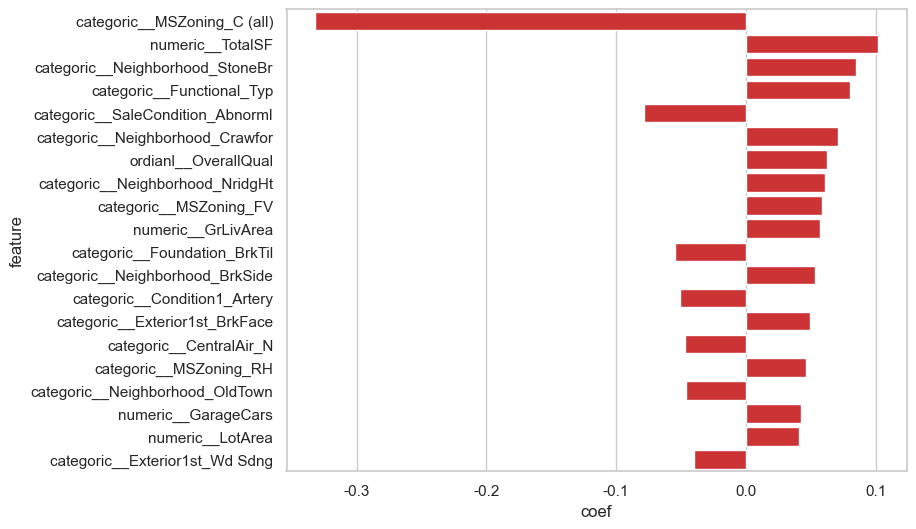

In [97]:
# 条形图
sns.barplot(data=high20_coef_features, x='coef', y='feature')

In [98]:
feature_coef_df[feature_coef_df['feature'] == 'categoric__SaleCondition_Abnorml']

,feature,coef,coef_abs
194,categoric__SaleCondition_Abnorml,-0.078678,0.078678


In [99]:
feature_coef_df['feature'].to_list()

['date__GarageYrBlt',
 'date__YearRemodAdd',
 'date__YearBuilt',
 'date__MoSold',
 'numeric__LotFrontage',
 'numeric__LotArea',
 'numeric__BsmtFinSF1',
 'numeric__BsmtFinSF2',
 'numeric__BsmtUnfSF',
 'numeric__TotalBsmtSF',
 'numeric__2ndFlrSF',
 'numeric__LowQualFinSF',
 'numeric__GrLivArea',
 'numeric__GarageArea',
 'numeric__WoodDeckSF',
 'numeric__OpenPorchSF',
 'numeric__EnclosedPorch',
 'numeric__3SsnPorch',
 'numeric__ScreenPorch',
 'numeric__PoolArea',
 'numeric__MiscVal',
 'numeric__BsmtFullBath',
 'numeric__BsmtHalfBath',
 'numeric__FullBath',
 'numeric__HalfBath',
 'numeric__BedroomAbvGr',
 'numeric__KitchenAbvGr',
 'numeric__TotRmsAbvGrd',
 'numeric__Fireplaces',
 'numeric__GarageCars',
 'numeric__HasBsmt',
 'numeric__TotalSF',
 'numeric__HouseSF_PRODUCT_QUAL',
 'ordianl__OverallQual',
 'ordianl__OverallCond',
 'ordianl__ExterQual',
 'ordianl__ExterCond',
 'ordianl__HeatingQC',
 'ordianl__KitchenQual',
 'categoric__MSSubClass_20',
 'categoric__MSSubClass_30',
 'categoric__M

效果是合理的。

解释：
1. MSZoning_C表示在商业区的房子，对房价负面影响大，价格就会低

### 假设验证

In [100]:
residuals = np.log(y_valid_pred) - np.log(y_valid)

In [101]:
residuals = residuals.rename(columns={'SalePrice': 'residual'})
residuals['price'] = y_valid
residuals['pred'] = y_valid_pred

In [102]:
residuals['residual'].skew()
residuals['residual'].kurt()

0.7928208043477891

In [103]:
residuals.head()

,residual,price,pred
Id,,,
901,-0.096132,110000,99917.879695
866,-0.113979,148500,132503.149770
103,0.000129,118964,118979.288769
351,-0.041645,318061,305087.301564
743,-0.015425,179000,176260.178689


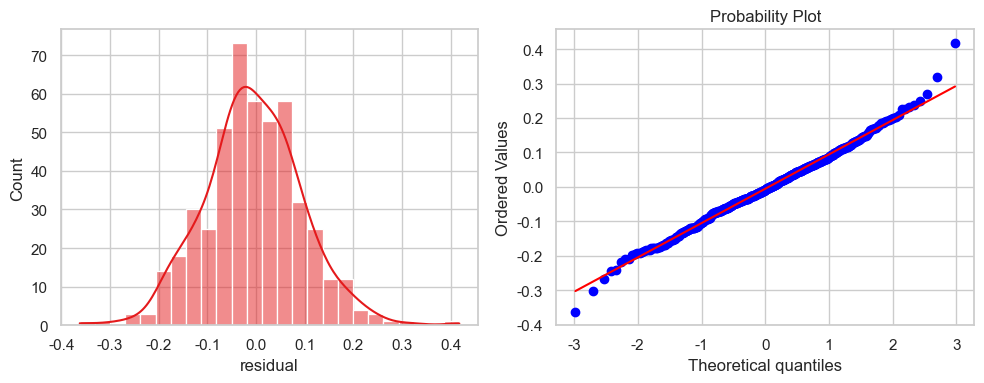

In [104]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
sns.histplot(data=residuals, x='residual',kde=True, ax= ax1)
res = stats.probplot(residuals['residual'], plot=ax2)
plt.tight_layout()
plt.show()

In [105]:
residuals[(residuals['residual'] < 0.2) & (residuals['residual'] >-0.2)].shape[0] / len(residuals)

0.9624217118997912

In [106]:
residuals['residual'].std()

0.09954724503378992

误差正态假设基本是成立的，在数据集中区域尤为明显。

残差在$[-0.2, 0.2]$的数据占比93%。 样本标准差为0.1，参数估计的话，
符合$2\sigma$内分布95%数据

那些离群点需要研究下,

### 离群
找出这些离群点的共同特点，

```{warning}
由于没有version控制，notebook不能够反映思路：通过训练再去修改eda过程

根据probplot划分左右

与 #剔除异常行 配合

#### 左侧
都是预测值小于真实值！

In [107]:
residuals[residuals['residual'] < -0.3]

,residual,price,pred
Id,,,
804,-0.362065,582933,405859.631373
49,-0.302780,113000,83480.065387


3个离散点，直接删除即可

#### 右侧

着重看下系数大于0的特征。`neighborhood`, `totalsf`

In [108]:
feature_coef_df[feature_coef_df['coef'] > 0].sort_values(by='coef', ascending=False).head(10)

,feature,coef,coef_abs
31,numeric__TotalSF,0.102064,0.102064
92,categoric__Neighborhood_StoneBr,0.085102,0.085102
181,categoric__Functional_Typ,0.080049,0.080049
76,categoric__Neighborhood_Crawfor,0.071365,0.071365
33,ordianl__OverallQual,0.062620,0.062620
86,categoric__Neighborhood_NridgHt,0.060607,0.060607
57,categoric__MSZoning_FV,0.058670,0.058670
12,numeric__GrLivArea,0.056887,0.056887
73,categoric__Neighborhood_BrkSide,0.053056,0.053056
130,categoric__Exterior1st_BrkFace,0.049454,0.049454


In [109]:
hard_mask = (residuals['residual'] > 0.2) 

In [110]:
hard_ids = residuals[hard_mask].index

In [111]:
hard_df = eda_data.loc[hard_ids, :]
hard_df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log,HasBsmt,HouseAge,TotalSF,HouseSF_PRODUCT_QUAL
Id,,,,,,,,,,,,,,,,,,,,,
772,20,RL,67.0,8877,Pave,NaN,Reg,Lvl,AllPub,Inside,...,1,1970,COD,Normal,102000,11.532728,1,0,1226.728629,4906.914514
711,30,RL,56.0,4130,Pave,NaN,IR1,Lvl,AllPub,Inside,...,1,1970,WD,Normal,52000,10.858999,1,0,734.598422,2203.795266
1384,30,RL,NaN,25339,Pave,NaN,Reg,Lvl,AllPub,Inside,...,1,1970,WD,Normal,112000,11.626254,1,0,1422.704414,7113.522072
745,120,RL,41.0,5395,Pave,NaN,IR1,HLS,AllPub,Inside,...,1,1970,WD,Normal,180000,12.100712,1,0,1344.198184,10753.585469
1164,90,RL,60.0,12900,Pave,NaN,Reg,Lvl,AllPub,Inside,...,1,1970,WD,Alloca,108959,11.598727,1,0,1265.088409,5060.353635


totalsf

<Axes: xlabel='TotalSF', ylabel='SalePrice'>

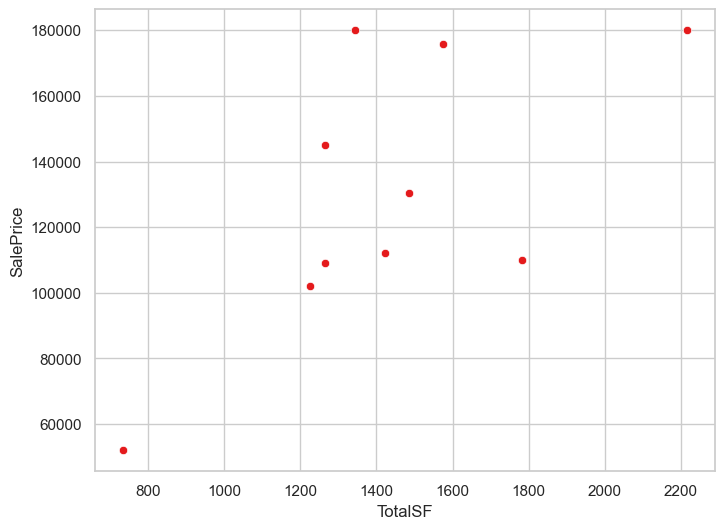

In [112]:
sns.scatterplot(data=hard_df, x='TotalSF', y='SalePrice')

In [113]:
hard_df[hard_df['TotalSF'] > 2250]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log,HasBsmt,HouseAge,TotalSF,HouseSF_PRODUCT_QUAL
Id,,,,,,,,,,,,,,,,,,,,,


saletype

In [114]:
hard_df['SaleType'].value_counts()

SaleType
WD     7
COD    3
Name: count, dtype: int64

WD是最普通的方式，没什么问题

<Axes: xlabel='SaleType', ylabel='SalePrice'>

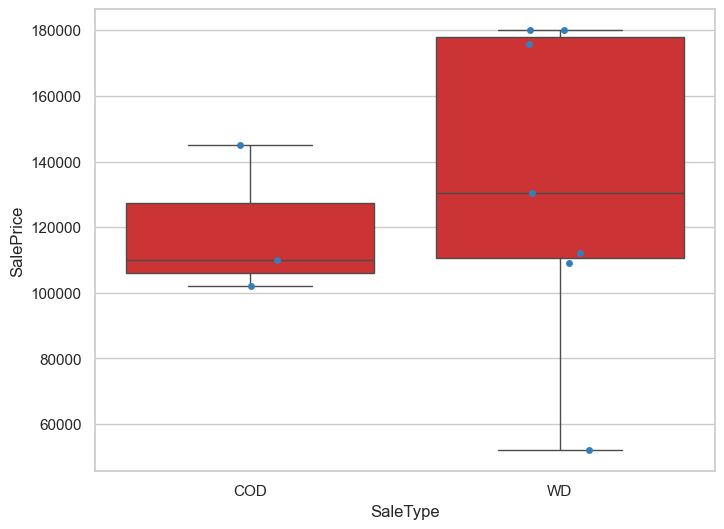

In [115]:
sns.boxplot(data=hard_df, x='SaleType', y='SalePrice')
sns.stripplot(data=hard_df, x='SaleType', y='SalePrice')

Neighborhood:StoneBr,NridgHt,Crawfor,NoRidge

<Axes: xlabel='Neighborhood', ylabel='SalePrice'>

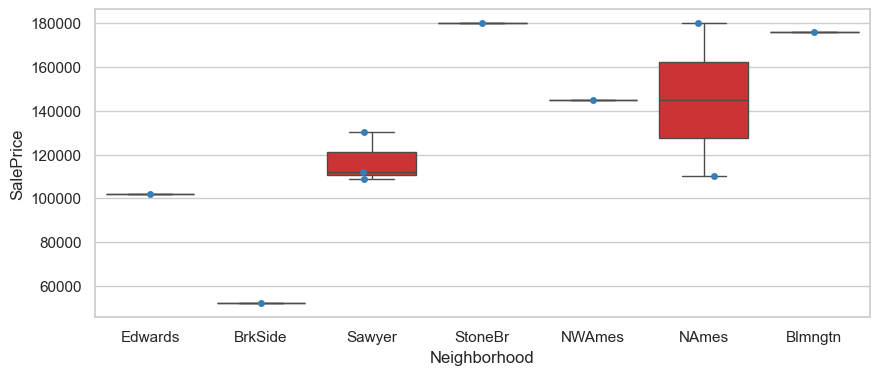

In [116]:
plt.figure(figsize=(10,4))
sns.boxplot(data=hard_df, x='Neighborhood', y='SalePrice')
sns.stripplot(data=hard_df, x='Neighborhood', y='SalePrice')

<Axes: xlabel='Neighborhood', ylabel='SalePrice'>

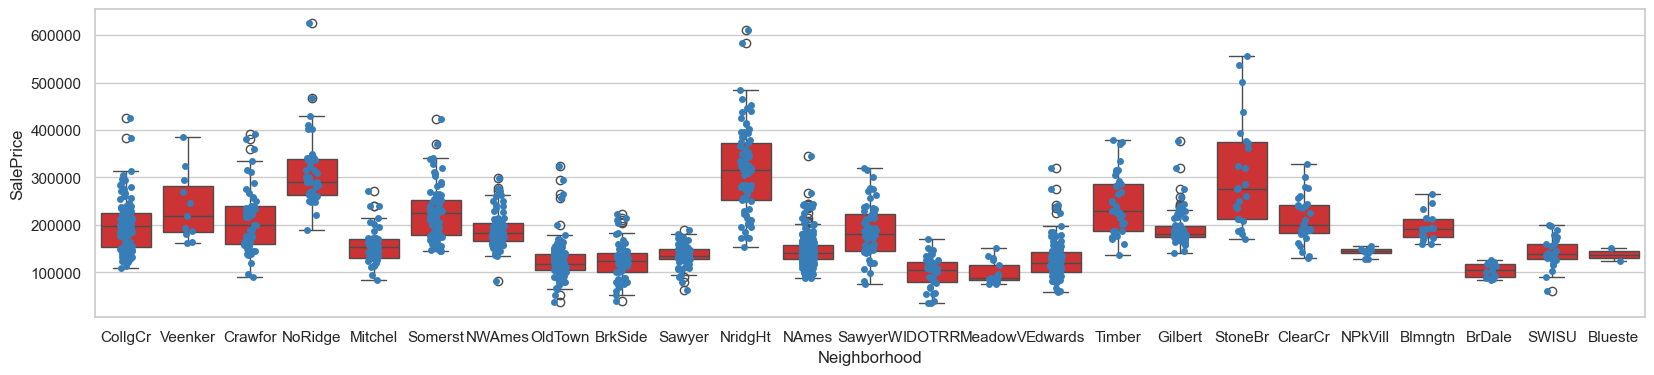

In [117]:
plt.figure(figsize=(20,4))
sns.boxplot(data=eda_data, x='Neighborhood', y='SalePrice')
sns.stripplot(data=eda_data, x='Neighborhood', y='SalePrice')

Functional_Typ

<Axes: xlabel='Functional', ylabel='SalePrice'>

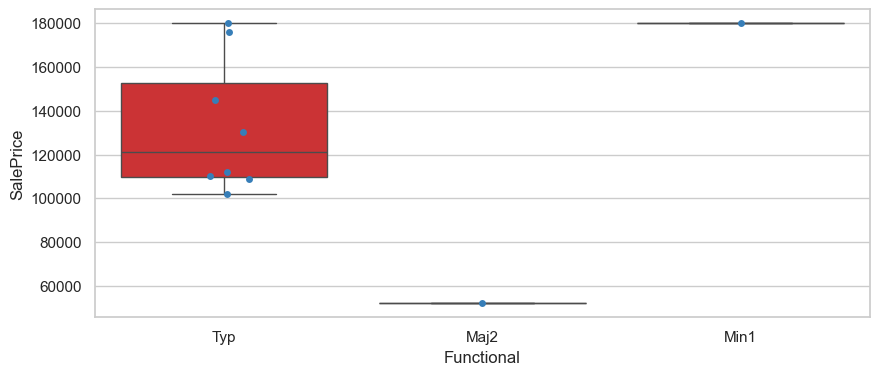

In [118]:
plt.figure(figsize=(10,4))
sns.boxplot(data=hard_df, x='Functional', y='SalePrice')
sns.stripplot(data=hard_df, x='Functional', y='SalePrice')

OverallQual

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

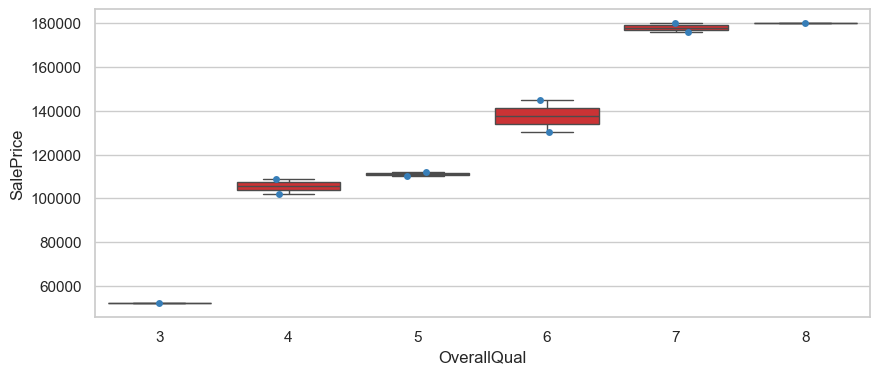

In [119]:
plt.figure(figsize=(10,4))
sns.boxplot(data=hard_df, x='OverallQual', y='SalePrice')
sns.stripplot(data=hard_df, x='OverallQual', y='SalePrice')

Exterior1st_BrkFace

<Axes: xlabel='Exterior1st', ylabel='SalePrice'>

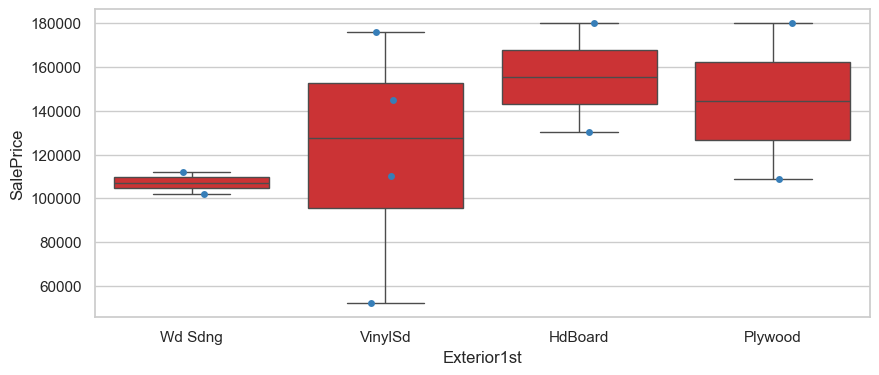

In [120]:
plt.figure(figsize=(10,4))
sns.boxplot(data=hard_df, x='Exterior1st', y='SalePrice')
sns.stripplot(data=hard_df, x='Exterior1st', y='SalePrice')

GrLivArea

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

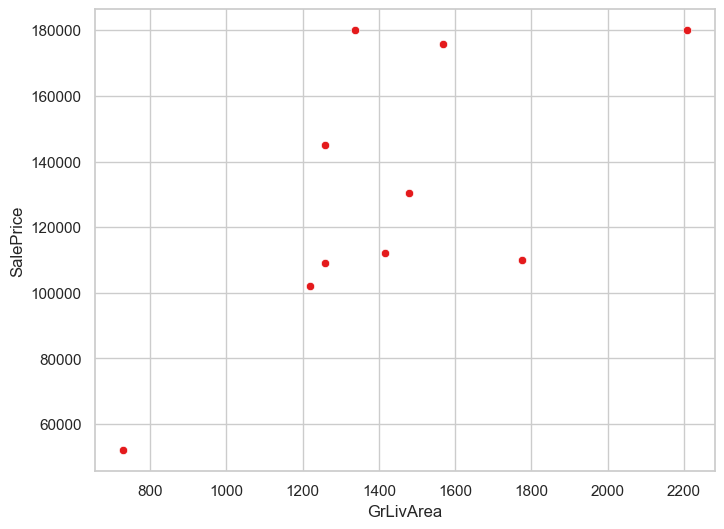

In [121]:
sns.scatterplot(data=hard_df, x='GrLivArea', y='SalePrice')

都没什么大问题，删除那个异常点试试

### submit

In [122]:
testdata.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [123]:
testdata.index

Index([1461, 1462, 1463, 1464, 1465, 1466, 1467, 1468, 1469, 1470,
       ...
       2910, 2911, 2912, 2913, 2914, 2915, 2916, 2917, 2918, 2919],
      dtype='int64', name='Id', length=1459)

In [124]:
preds = model_lasso.predict(testdata)

feature_features transformer done. 
fix_map_encoder transformer done.


In [126]:
submit(testdata.index, preds.flatten(), name='lasso_baseline', feature_count= len(feature_coef_df))

,ID,SalePrice
0,1461,122534.862603
1,1462,171915.586727
2,1463,180048.247839
3,1464,203875.194099
4,1465,204187.745363
...,...,...
1454,2915,85334.197869
1455,2916,82654.669512
1456,2917,176369.950479
1457,2918,116358.823686


得分0.13

至此，完成了最基本的训练、特征工程。如需提升，则要 ！特征选择